In [1]:
import torch
from torch import nn
import torchvision.transforms as transforms

# only for showing images
import numpy as np

import math
import os
from enum import Enum
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import DataLoader

In [ ]:
"""
notation:

{v}, {h}, etc. --> refers to the whole set of nodes
"""

'\npytorch, none of that "fit" woke agenda\n\nnotation:\n\n{v}, {h}, etc. --> refers to the whole set of nodes\n'

TO RUN ON GOOGLE_COLAB

-chose the tpu before, then it sets up the right cuda env

In [2]:
## set runtime, needs the gpu to run
if torch.backends.mps.is_available():
  device = torch.device("mps")
  x = torch.ones(1, device=device)
  print (x)
elif torch.backends.cuda.is_built():
  device = torch.device("cuda")
  x = torch.ones(1, device=device)
  print (x)
else:
  print ("GPU not found.")

tensor([1.], device='mps:0')


DATA

In [3]:
# download dataset
dataset = load_dataset("mnist")

# if using colab
# dataset = load_dataset("ylecun/mnist")

In [4]:
# data preprocessing

# convert  Image to Tensor, flatten (28x28 -> 784), and binarize
# RBMs require binary visible inputs

transform = transforms.ToTensor()

# Preprocessing for RBM

def preprocess_images_flat(batch):
    imgs = [transform(img) for img in batch["image"]]
    # flatten to mini_batch_size x 784
    imgs = torch.stack(imgs).view(
        -1, 784
    )  
    # binarize inputs
    imgs = (imgs > 0.5).float()  
    batch["image"] = imgs
    return batch


train_dataset_flat = dataset["train"].with_transform(preprocess_images_flat)
test_dataset_flat = dataset["test"].with_transform(preprocess_images_flat)

# Preprocessing for CNN

def preprocess_images_conv_tensor(batch):
    # keep native image shape: [1, 28, 28] per image (channel-first, unflattened)
    imgs = [transform(img) for img in batch["image"]]
    imgs = torch.stack(imgs)  # -> [batch_size, 1, 28, 28]
    batch["image"] = imgs
    return batch

train_dataset_cnn = dataset["train"].with_transform(preprocess_images_conv_tensor)
test_dataset_cnn = dataset["test"].with_transform(preprocess_images_conv_tensor)


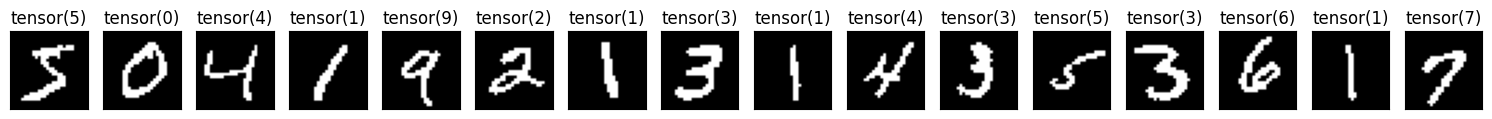

In [5]:
# inspection

# how many
imageN = 16

def plot_image_and_label(image, label):
    # loop through first @imageN images ([:@imageN]) and display the image (X) + the label (y)
    plt.figure(figsize=(imageN+3,5))
    for i, (image, label) in enumerate(zip(image[:imageN].view(imageN, 28, 28), label[:imageN])):
        plt.subplot(1, imageN, 1 + i)
        plt.imshow(image.numpy(), cmap='gray')
        plt.xticks([])
        plt.yticks([])
        plt.title(label)


X_train_show = train_dataset_flat[:imageN]['image'] 
y_train_show = torch.tensor(train_dataset_flat[:imageN]['label'])

# X_test_show = test_dataset[:imageN]['image']
# y_test_show = torch.tensor(test_dataset[:imageN]['label'])

plot_image_and_label(X_train_show, y_train_show)


#### CNN CLASSIFICATION MODEL FOR RBM TRAINING EVALUATIONS

CNN classifier model trained on MINST dataset to track Distribution of generated image
saved pre trained example on the following configuration has 98.36% accuracy.

In [6]:
### MODEL

""" 
    slightly changed from:
    https://github.com/stabgan/CNN-classification-of-MNIST-dataset-using-pyTorch/blob/master/cnn.py
    thank you
"""

class CNNModel(nn.Module):
    """
    Two-layer CNN for MNIST digit classification.
    """

    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()

        # Max pool 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # Max pool 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected 1 (readout)
        self.fc1 = nn.Linear(32 * 4 * 4, 10)

    def forward(self, x):
        # Convolution 1
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max pool 1
        out = self.maxpool1(out)

        # Convolution 2
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max pool 2
        out = self.maxpool2(out)

        # Reshape: (batch, 32, 4, 4) → (batch, 512)
        out = out.view(out.size(0), -1)

        # Linear function (readout)
        out = self.fc1(out)

        return out
    
### EVAL

def evaluate_cnn(model, test_loader, device):
    """Evaluate model accuracy on the test set."""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for idx, batch in enumerate(test_loader):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total

### INIT MODEL/DATA_LOADER/HYPERPARAMS

batch_size_cnn = 100
n_iters_cnn = 10000
learning_rate_cnn = 0.01

model_cnn = CNNModel().to(device)

num_epochs_cnn = int(n_iters_cnn / (len(train_dataset_cnn) / batch_size_cnn))

# PyTorch dataLoader for training and test sets
train_loader_cnn = torch.utils.data.DataLoader(
        dataset=train_dataset_cnn, batch_size=batch_size_cnn, shuffle=True
    )
test_loader_cnn = torch.utils.data.DataLoader(
    dataset=train_dataset_cnn, batch_size=batch_size_cnn, shuffle=False
    )

def train_cnn(model, train_loader, test_loader, num_epochs, learning_rate, device):
    """Train the CNN and evaluate every 500 iterations."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    iter_count = 0
    for epoch in range(num_epochs):
        model.train()
        for idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            iter_count += 1

            if iter_count % 500 == 0:
                accuracy = evaluate_cnn(model, test_loader, device)
                print(
                    f"Iteration: {iter_count}. Loss: {loss.item():.4f}. "
                    f"Accuracy: {accuracy:.2f}%"
                )

#### TRAIN FOR CNN

or load the already trained model (preferred)

In [7]:
# train_cnn(model_cnn, train_loader_cnn, test_loader_cnn, num_epochs_cnn, learning_rate_cnn, device)

In [8]:
### SAVE
DIR_CNN = 'classification_models/'
FILE_NAME_CNN = 'eval_classification_model_cnn.pt'
PATH_CNN = DIR_CNN + FILE_NAME_CNN

In [9]:
def save_model_cnn(model, path="cnn_mnist.pt"):
    """Save model weights to local storage."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def load_model_cnn(path="cnn_mnist.pt", device=device):
    """Load model weights into a fresh CNNModel instance."""
    model = CNNModel().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Model loaded from {path}")
    return model

In [10]:
### LOAD
DIR_CNN = 'classification_models/'
FILE_NAME_CNN = 'eval_classification_model_cnn.pt'
PATH_CNN = DIR_CNN + FILE_NAME_CNN

# save_model_cnn(model_cnn, path=PATH_CNN)

classification_model_1 = load_model_cnn(path=PATH_CNN)

Model loaded from classification_models/eval_classification_model_cnn.pt


#### HELPFUL EVAL FUNCTIONS WITH THE CNN CLASSIFIER

In [11]:
### for loader_cnn (the tensor one [B, 28, 28, 1])
def cnn_get_classification_distribution(model_cnn, images, device, num_classes=10):
    """
    Run the model on a batch of N images and return the distribution
    of predicted classes.

    Returns:
        counts: dict {class_label: raw count}
        fractions: dict {class_label: count / N}
        N: total number of images
    """
    model_cnn.eval()
    images = images.to(device)
    N = images.size(0)

    with torch.no_grad():
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)

    counts = {c: 0 for c in range(num_classes)}
    for p in predicted.tolist():
        counts[p] += 1

    fractions = {c: counts[c] / N for c in range(num_classes)}
    return counts, fractions, N

### for loader_flat/rbm (the flattened one [B, 784])
def flat_get_classification_distribution(model, images, device, num_classes=10, image_shape=(1, 28, 28)):
    """
    Run the model on a batch of N images and return the distribution
    of predicted classes.

    `images` can be:
      - already shaped [N, 1, 28, 28] (e.g. from the CNN dataloader), or
      - flat [N, 784] (e.g. RBM-generated samples) — will be reshaped automatically.

    Returns:
        counts: dict {class_label: raw count}
        fractions: dict {class_label: count / N}
        N: total number of images
    """
    model.eval()

    if images.dim() == 2:
        images = images.view(-1, *image_shape)

    images = images.to(device)
    N = images.size(0)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    counts = {c: 0 for c in range(num_classes)}
    for p in predicted.tolist():
        counts[p] += 1

    fractions = {c: counts[c] / N for c in range(num_classes)}
    return counts, fractions, N

def plot_dataset_samples(images: torch.Tensor, labels: torch.Tensor, model=None, device=None, n=36):
    """
    Displays up to n images (shape [N, 1, 28, 28]) in a 6x6-style grid,
    showing the true label and, if a model is provided, the predicted label.
    """
    n = min(n, images.size(0))
    grid_size = int(n ** 0.5)
    if grid_size * grid_size < n:
        grid_size += 1

    images_cpu = images[:n].cpu()
    labels_cpu = labels[:n].cpu()

    predicted = None
    if model is not None:
        model.eval()
        with torch.no_grad():
            outputs = model(images[:n].float().to(device))
            _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
    fig.suptitle("Dataset Samples", fontsize=16, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        if i < n:
            img_tensor = images_cpu[i].squeeze(0)  # [1,28,28] -> [28,28]
            true_label = labels_cpu[i].item()

            ax.imshow(img_tensor, cmap="gray")
            if predicted is not None:
                pred_label = predicted[i].item()
                ax.set_title(f"y={true_label}  ŷ={pred_label}", fontsize=9)
            else:
                ax.set_title(f"y={true_label}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_distribution_histogram(counts, N, title="Predicted Class Distribution"):
    """Bar chart of class counts."""
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]

    plt.figure(figsize=(8, 4))
    plt.bar(classes, values, color="steelblue")
    plt.xticks(classes)
    plt.xlabel("Class")
    plt.ylabel(f"Count (out of {N})")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def build_compact_distribution_string(counts, N):
    """
    Compact one-row 'table' string, e.g.:
    0:12/100 | 1:9/100 | 2:11/100 | 3:8/100 | ...
    """
    return " | ".join(f"{c}:  {counts[c]}/{N}" for c in sorted(counts))

0:  9/100 | 1:  14/100 | 2:  10/100 | 3:  12/100 | 4:  9/100 | 5:  5/100 | 6:  14/100 | 7:  13/100 | 8:  5/100 | 9:  9/100


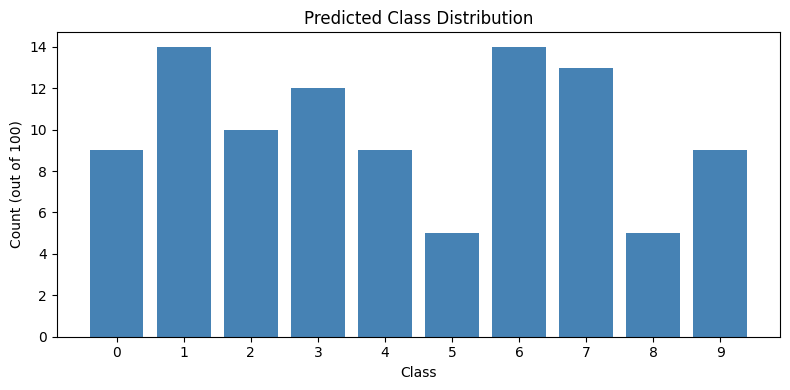

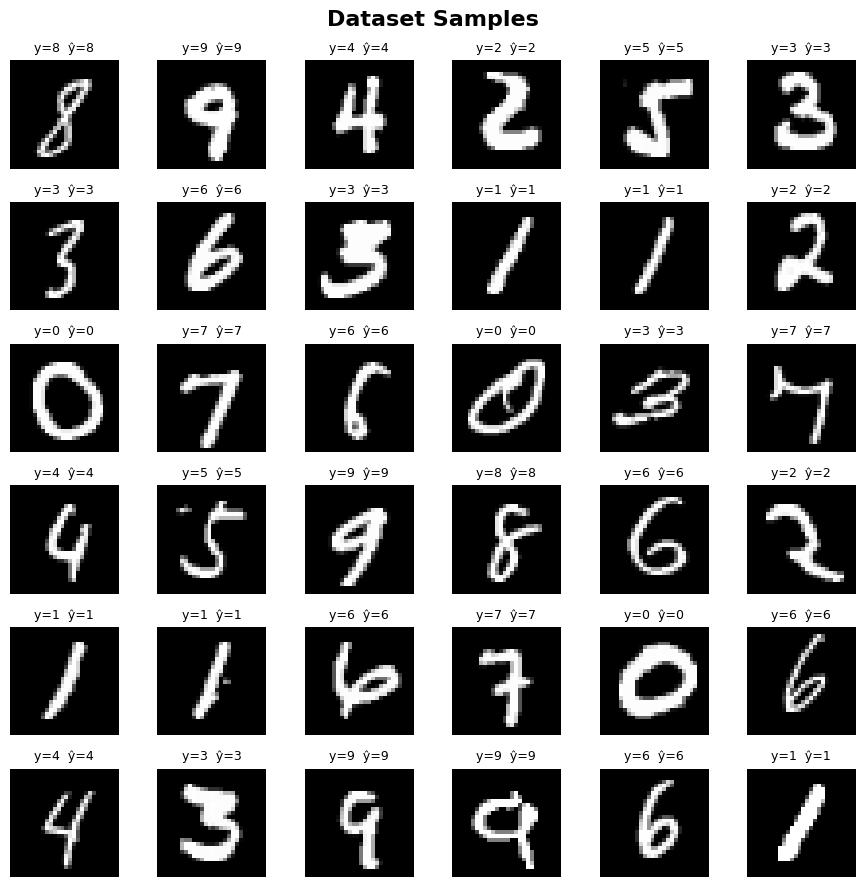

In [12]:
### test plotting

# grab a sample of N images from the test set
sample_batch = next(iter(train_loader_cnn))
sample_images = sample_batch["image"][:100]  # N = 50
sample_labels = sample_batch["label"][:100]


counts, fractions, N = cnn_get_classification_distribution(classification_model_1, sample_images, device)

print(build_compact_distribution_string(counts, N))
# e.g. 0:6/50 | 1:4/50 | 2:5/50 | 3:5/50 | 4:6/50 | 5:4/50 | 6:5/50 | 7:5/50 | 8:5/50 | 9:5/50

plot_distribution_histogram(counts, N)
plot_dataset_samples(sample_images, sample_labels, model=classification_model_1, device=device, n=36)

RBM MODEL

In [13]:
# MCMC optimizations choice
class TrainingMode(Enum):
    CD_K = "cd_k"
    PCD_K = "pcd_k"

# sampling strategy choice
class SamplingMode(Enum):
    STANDARD = "standard"
    PARALLEL_TEMPERING = "parallel_tempering"
    TROTTER_SUZUKI = "trotter_suzuki"

class RBM (nn.Module): 
    """ 
    Restricted Boltzmann Machine model\n
    contrastive divergence \n
    hidden unit sparsity penalty on loss value\n
    standard thermal annealing in generation\n
    takes the whole training data in the __init__ to calculate the visible biases
    """
    
    # =============================================================  initialize  ======================================================================
    
    # initialize the parameters 
    def __init__(self, training_data: torch.Tensor, hidden_N,
                 # cd_k/pcd_k
                 CDK_limit = 3,
                 # parallel tampering thermal annealing
                 pt_num_temp_plains = 5, pt_temp_max = 2.0,
                 # trotter suzuki slices "quantum" annealing
                 ts_num_slices = 4, ts_gamma_init = 2.0, ts_gamma_final = 0.05, ts_coupling_scale = 1e-3,
                 # pcd_k params
                 pfc_to_batch_ratio = 5, pfc_chain_reset_p = 0.02,
                 # sparsity penalty
                 sparsity_target = 0.02, sparsity_cost = 0.02, sparsity_decay = 0.90,
                 # mode stability penalty
                 mode_stability_walk_steps = 30, mode_stability_cost = 0.05, mode_stability_margin = 0.0, mode_stability_batch_fraction = 1, 
                 # training controls
                 use_sparsity = True, use_mode_stab_penalty = False, 
                 ):
        # superclass init
        super().__init__()
        
        # setup model hyperparameters and input features
        sample_img = training_data[0]['image']
        self.visible_nodes_N = sample_img.numel()
        self.hidden_nodes_N = hidden_N
        # default cdk
        self.contrastive_divergence_K_limit = int(CDK_limit)
        
        # {w_ij}
        # init weights randomly
        # matrix h*v, small [0,1] range initialization for all weights
        # std = 0.01 as per textbook {Charu C. Aggarwal}
        self.weights = nn.Parameter(torch.randn(self.visible_nodes_N,
                                            self.hidden_nodes_N) * 0.01)
        
        # {h_b}, all set to zero as per textbook {Charu C. Aggarwal}
        self.H_biases = nn.Parameter(torch.zeros(self.hidden_nodes_N))
        
        # PRE-Training
        print("starting pre-training of visible biases...")
        # {v_b}
        # stack images from data
        all_images = torch.stack([item['image'].view(-1).float() for item in training_data])
        # so it doesn't divide by zero
        epsilon = 1e-5 
        # biases set the initial visible biases to log[p_i / (1 - p_i)
        # with probability in [0,1] range
        p_i = torch.clamp(torch.mean(all_images, dim=0), min=epsilon, max=1.0 - epsilon)
        self.V_biases = nn.Parameter(
            torch.log(p_i / (1.0 - p_i))
        )                
        print("pre-training finished")
        
        # PT hyperparams
        # number of replica chains spanning temperature 1.0 (real model) -> pt_temperature_max
        self.pt_num_temp_plains = int(pt_num_temp_plains)
        # max temperature to schedule the parallel plains to
        self.pt_temp_max = float(pt_temp_max)

        # Trotter-Suzuki slices hyperparameters
        # num of parallel slices in the circle
        self.ts_num_slices = int(ts_num_slices)
        # initial 'temperature' - gamma: traverse field strength
        self.ts_gamma_init = float(ts_gamma_init)
        # final 'temperature' - gamma: traverse field strength
        self.ts_gamma_final = float(ts_gamma_final)
        # scaler to adjust so the gamma is within reasonable value of alpha lr
        self.ts_coupling_scale = float(ts_coupling_scale)
        
        # Persistent Contrastive Divergence Hyperparameters
        # number of persistent fantasy chains to sample from at the begging of PCD-K
        self.pfc_to_batch_ratio = float(pfc_to_batch_ratio)
        self.persistent_fantasy_chains_N = None
        # persistent fantasy chains buffer for PCD 
        self.register_buffer('persistent_fantasy_chains_store', None, persistent=False)
        # chance of a chain from the store resetting before each gibbs sampling step - prevents modal collapse
        self.pfc_chain_reset_p = float(pfc_chain_reset_p)

        # full PT ladder buffer, shape (M, persistent_fantasy_chains_N, visible_nodes_N)
        # stores every plain's state per fantasy-chain slot, so hot/mid plains
        # keep their own persistent trajectory across training steps too, not
        # just the cold (beta=1) plain. Only relevant when PCD_K + PARALLEL_TEMPERING.
        self.register_buffer('pt_plains_store', None, persistent=False)
        
        # Sparsity Encouragement hyperparameters, Hinton's recipe default values
        # p << 1 (0.01 - 0.19), how often should a hidden unit activate on average in a mini batch
        self.sparsity_target = float(sparsity_target)  
        # buffer to track running mean activation q_running across batches for hidden unit sparsity penalty
        self.register_buffer('q_running', torch.full((self.hidden_nodes_N,), self.sparsity_target))
        # sparsity penalty scaler
        self.sparsity_cost = float(sparsity_cost)      
        # decay rate for EMA (0.9 - 0.99)
        self.sparsity_decay = float(sparsity_decay) 
        # default = ON   
        self.use_sparsity = use_sparsity
        
        # Mode Stability Penalty Hyperparameters
        # gibbs sampling steps to get the model processed visible vector
        self.mode_stability_walk_steps = int(mode_stability_walk_steps)
        # margin of error allowed, increased the free energy of walked vector (reduces probability)
        self.mode_stability_margin = float(mode_stability_margin)
        # fraction of batch to compute the penalty on, best = 1.0 on small batches like 20
        self.mode_stability_batch_fraction = float(mode_stability_batch_fraction)
        # scaler when adding to the training loss
        self.mode_stability_cost = float(mode_stability_cost)
        # on/off
        self.use_stability_penalty = use_mode_stab_penalty
    
    # ========================================================  energy / free energy  =================================================================    
        
    # function to calculate the energy of the network (loss function)
    def energy_function(self, v_states, h_states) -> torch.Tensor:
        """ 
            do you even need this
        """
        # E = - v_states*v_biases - h_states*h_biases - sum_over_pair_ij( weight_ij*vi_state*hj_state )
        #                                                                 <i,j> neurone interaction
        v = torch.matmul(v_states, self.V_biases)
        h = torch.matmul(h_states, self.H_biases)
        interaction = torch.sum(torch.matmul(v_states, self.weights) * h_states, dim=1)
        return - v - h - interaction
    
    # free energy 
    def free_energy_visible(self, v_states, temperature=1):
        """ 
        E(v) -- the energy state of the visible states vector, better for contrasting with training vectors.
        Doesn't include hidden states activation, apart from their signals to the visible vectors.
        """
        
        #                              hidden states input
        # F(v) = - v_states*v_biases - SUM_OVER[ (v_states * weights) + h_biases ]
        
        v = torch.matmul(v_states, self.V_biases)
        # how the hidden states are activated by their biases and the visible states connections
        h_signals = ((torch.matmul(v_states, self.weights) + self.H_biases) 
                        / temperature)
        # accumulates and the hidden states input to the function
        weights_v_and_h_biases = torch.sum(torch.nn.functional.softplus(h_signals), dim = 1)
        
        return - v - weights_v_and_h_biases
    
    # ====================================================  states re-sampling functions  =============================================================   
    
    # stochastic probability of state change for hidden nodes
    def h_states_stochastic(self, v_states_batch, temperature=1):
        """ 
        calculates the probabilities of {h} given w, {v} and {h_bias} \n
        RETURNS the stochastic hidden states from those probabilities as floats \n
        Batch size needs to be in shape[0] of the passed parameter \n
        temperature should be off (=1) during training for data gen models
        """
    
        # P of ({h}[j] = 1 | {v} ) 1 / ( 1 + e^( - biases_h[j] - SUMMATION_OVER_V_STATES[i](v[i]*w[i,j]) ))
        
        # long formula not used because of numerical instabilities, sigmoid instead
        # matrix of 1s of dimensions equal to the amount of visible nodes passed times 
        # the mini batching of training algorithm
        #                                 mini batch size          number of h nodes
        # ones_hidden_batch = torch.ones((v_states_batch.shape[0], self.hidden_nodes_N))
        # p_of_hidden_states_batch = ( ones_hidden_batch /
        #     (ones_hidden_batch + 
        #      torch.exp( - self.H_biases - torch.matmul(v_states_batch,self.weights))) )
        
        activation_force = ((self.H_biases + torch.matmul(v_states_batch, self.weights)) 
                            / temperature)
        # activation_force = self.H_biases + torch.matmul(v_states_batch, self.weights)
        p_of_hidden_states_batch = torch.sigmoid(activation_force)
        
        # print(f"p_of_hidden_states shape: {p_of_hidden_states.shape}")      

        # "coin flip" the probability to get the batched set of hidden states  
        # also passes back the probability values         
        # p_h_clamped = torch.clamp(p_of_hidden_states_batch, min=0.0, max=1.0)        
        h_states = torch.bernoulli(p_of_hidden_states_batch)
        
        return p_of_hidden_states_batch, h_states
    
    # stochastic probability of state change for visible nodes
    def v_states_stochastic(self, h_states_batch, temperature=1):
        """ 
        calculates the probabilities of {v} given w, {h} and {v_bias} \n
        RETURNS the stochastic visible states from those probabilities as floats \n
        Batch size needs to be in shape[0] of the passed parameter \n
        temperature should be off (=1) during training for data gen models
        """
        # P of ({v}[i] = 1 | {h} ) 1 / ( 1 + e^( - biases_v[i] - SUMMATION_OVER_H_STATES[j](h[j]*w[i,j])))
        
        # long formula not used because of numerical instabilities, sigmoid instead
        # matrix of 1s of dimensions equal to the amount of visible nodes passed times 
        # the mini batching of training algorithm
        #                                mini batch size          number of v nodes
        # ones_visible_batch = torch.ones((h_states_batch.shape[0], self.visible_nodes_N)) 
        # p_of_visible_states_batch = ( ones_visible_batch /
        #     (ones_visible_batch + 
        #      torch.exp( - self.V_biases - torch.matmul(h_states_batch, self.weights.t()))) )
        
        # each column of the weights tensor is like all the values for one hidden node,
        # so when it's transposed on columns corresponds to all weights for a visible node
        
        activation_force = ((self.V_biases + torch.matmul(h_states_batch, self.weights.t()))
                            / temperature)
        # activation_force = self.V_biases + torch.matmul(h_states_batch, self.weights.t())
        p_of_visible_states_batch = torch.sigmoid(activation_force)
        
        # "coin flip" the probability to get the batched set of visible states 
        # also passes back the probability values       
        # p_v_clamped = torch.clamp(p_of_visible_states_batch, min=0.0, max=1.0)                    
        v_states = torch.bernoulli(p_of_visible_states_batch)
        
        return p_of_visible_states_batch, v_states
    
    # ==========================================================  sample generation  ==================================================================
    
    # generate data
    def gibbs_data_gen_TA(self, num_samples, gibbs_steps=1000, use_thermal_annealing = True, initial_temperature=1.5) :
        """
            gibbs sampling to do data generation
            with Thermal Annealing \n
            returns visible_vector_probabilities, vector_sampled_energy, hidden_vector_probabilities
        """
        
        was_training = self.training
        self.eval()
        device = self.weights.device
        
        with torch.no_grad():
            # init visible state with binary noise
            v = torch.bernoulli(
                torch.full((num_samples, self.visible_nodes_N), 0.5, device=device)
            )
            # gibbs sampling loop
            for i in range(gibbs_steps):
                # update energy
                t = (self.get_current_temperature(i, initial_temperature, gibbs_steps) 
                    if use_thermal_annealing 
                    else 1.0)
                h_prob, h = self.h_states_stochastic(v, temperature=t)
                v_prob, v = self.v_states_stochastic(h, temperature=t)
        
        # compute the hidden states to for statistical analysis of sparsity in testing
        
        h_prob, _ = self.h_states_stochastic(v_prob)
        energies = self.free_energy_visible(torch.bernoulli(v_prob))
        
        if was_training:
            self.train()
        # return the v_prob_vector, and it's energies
        return v_prob, energies, h_prob
    
    # ==================================================== utility and penalty functions  =============================================================
    
    # get current temperature for gibbs data generation
    def get_current_temperature(self, current_step, initial_temperature, gibbs_steps):
        """ 
            this function returns what should be the current temperature in the decay schedule
            controlled by the current gibbs step, and the max gibbs sampling steps
        """
        # if 1, return 1 (or minimum)
        if gibbs_steps <= 1:
            return initial_temperature

        # Exponential decay factor
        decay_rate = ((1 / initial_temperature) 
                        ** (1.0 / (gibbs_steps - 1)))
        temp = initial_temperature * (decay_rate ** current_step)
        return max(temp, 1)
    
    # Parallel Tampering
    
    # parallel tampering sample from parallel plains with higher temps, return the final
    # cooled down, relatively "noiseless" sample safe for gradient backpropagationg
    def _sample_negative_phase_pt(self, v_init, k_steps, plains_init=None, return_all_plains=False):
        """
        Replica-exchange negative-phase sampler. Runs pt_num_temp_plains plains
        at temperatures spaced between 1.0 (the real model) and pt_temp_max.
        Each step: ordinary Gibbs update per plain at its own temperature, then
        stochastic adjacent-temperature swaps via _pt_swap_probability. Hotter
        plains mix faster and help the beta=1 plain escape local modes.
    
        Temperatures are spaced geometrically, T_i = T_1 * gamma^(i-1) with
        gamma > 1, rather than linearly. This works well when the system's
        heat capacity is roughly constant, and clusters more plains near the
        cold target T=1, where the probability landscape changes most rapidly
        and swap acceptance is most sensitive to spacing.
    
        If plains_init is given (list of M tensors), the ladder resumes from
        those states instead of cloning v_init into every plain - lets all M
        plains persist their own trajectory across calls (e.g. across PCD
        training steps), rather than only the cold plain surviving via v_init.
        If return_all_plains is True, also returns the full list of M final
        plain states so the caller can store them for next time.
    
        Returns (v_prob, v_state) from the beta=1 plain, plus plains if
        return_all_plains is True.
        """
        device = v_init.device
        M = self.pt_num_temp_plains
    
        # geometric spacing: T_i = T_1 * gamma^(i-1), T_1 = 1.0, T_M = pt_temp_max
        gamma = self.pt_temp_max ** (1.0 / (M - 1))
        temperatures = 1.0 * gamma ** torch.arange(M, device=device, dtype=torch.float32)
        betas = 1.0 / temperatures
    
        # resume the ladder from persisted plain states if given, else cold-start all M from v_init
        if plains_init is not None:
            plains = [p.clone() for p in plains_init]
        else:
            plains = [v_init.clone() for _ in range(M)]
    
        # gibbs steps
        for _ in range(k_steps):
            for m in range(M):
                _, h_m = self.h_states_stochastic(plains[m], temperature=temperatures[m].item())
                _, v_m = self.v_states_stochastic(h_m, temperature=temperatures[m].item())
                plains[m] = v_m
    
            with torch.no_grad():
                for m in range(M - 1):
                    F_m = self.free_energy_visible(plains[m])
                    F_m1 = self.free_energy_visible(plains[m + 1])
                    p_swap = self._pt_swap_probability(F_m, F_m1, betas[m], betas[m + 1])
                    swap_mask = (torch.rand_like(p_swap) < p_swap).unsqueeze(1)
                    new_m  = torch.where(swap_mask, plains[m + 1], plains[m])
                    new_m1 = torch.where(swap_mask, plains[m],     plains[m + 1])
                    plains[m], plains[m + 1] = new_m, new_m1
    
        _, h_final = self.h_states_stochastic(plains[0])
        v_prob_final, _ = self.v_states_stochastic(h_final)
    
        if return_all_plains:
            return v_prob_final, plains[0], plains
        return v_prob_final, plains[0]

    # hastings-metropolis p for swaps of adjacent temp plains
    def _pt_swap_probability(self, F_i, F_j, beta_i, beta_j):
        """
        Metropolis acceptance probability for swapping two parallel-tempering
        plains' states, using free energy as the effective energy
        (Desjardins et al. 2010): p_swap = min(1, exp((beta_i - beta_j)(F_i - F_j)))
        F_i, F_j are per-sample free energy tensors (batch,).
        """
        delta = (beta_i - beta_j) * (F_i - F_j)
        return torch.clamp(torch.exp(delta), max=1.0)
    
    
    ### Trotter Suzuki 
    def _sample_negative_phase_trotter_suzuki(self, v_init, k_steps):
        """
        ts_num_slices coupled classical copies of the visible state each run
        ordinary Gibbs updates, then get nudged toward their ring-neighbors
        slices by a coupling term annealed up over the walk (see
        _get_ts_schedule). Early on (large Gamma) slices explore fairly
        independently; by the end (Gamma -> 0) they're forced into consensus,
        recovering an ordinary classical sample. Returns slice 0 after collapse.
        """
        P = self.ts_num_slices
        slices = [v_init.clone() for _ in range(P)]

        for step in range(k_steps):
            _, j_perp = self._get_ts_schedule(step, k_steps)
            new_slices = []
            for p in range(P):
                left = slices[(p - 1) % P]
                right = slices[(p + 1) % P]

                _, h_p = self.h_states_stochastic(slices[p])

                base_force = self.V_biases + torch.matmul(h_p, self.weights.t())
                # Ising-style {-1,+1} agreement term with ring neighbors
                neighbor_agreement = (2 * left - 1) + (2 * right - 1)
                v_p_prob = torch.sigmoid(base_force + j_perp * neighbor_agreement)
                new_slices.append(torch.bernoulli(v_p_prob))
            slices = new_slices

        _, h_final = self.h_states_stochastic(slices[0])
        v_prob_final, _ = self.v_states_stochastic(h_final)
        return v_prob_final, slices[0]
        
    
    def _get_ts_schedule(self, step, total_steps):
        """
        Anneals the transverse field Gamma from ts_transverse_field_init down to
        ts_transverse_field_final, and derives an inter-slice coupling strength
        via the Suzuki-Trotter mapping used in simulated quantum annealing:
            J_perp = -0.5 * ln(tanh(Gamma / P))
        scaled by ts_coupling_scale (units aren't physically well-defined for an
        RBM's binary states the way they are for an Ising spin system - this is
        a heuristic borrowing, not a literal derivation). As Gamma -> 0, J_perp
        grows large and forces the slices into agreement (classical limit).
        """
        if total_steps <= 1:
            gamma = self.ts_gamma_init
        else:
            frac = step / (total_steps - 1)
            gamma = (self.ts_gamma_init
                    + frac * (self.ts_gamma_final - self.ts_gamma_init))
        gamma = max(gamma, 1e-4)
        P = self.ts_num_slices
        j_perp = -0.5 * math.log(math.tanh(gamma / P))
        return gamma, self.ts_coupling_scale * j_perp

    
    # hidden units activation sparsity penalty calculation function
    def _compute_sparsity_penalty(self, p_h_pos: torch.Tensor) -> torch.Tensor:
        """ 
            function used to calculate the penalty that needs to be added to the loss during training when sparsity encouragement
            is enabled, it uses a moving average
        """
        # q_current carries autograd history back to weights & hidden biases
        q_current = torch.mean(p_h_pos, dim=0)
        
        if self.training:
            with torch.no_grad():
                # update q_running buffer
                self.q_running.mul_(self.sparsity_decay).add_(q_current.detach(), alpha=1.0 - self.sparsity_decay)
            # combine running average (for stability) with current batch (for autograd history)
            q_effective = self.sparsity_decay * self.q_running + (1.0 - self.sparsity_decay) * q_current
        else:
            # if not training?
            q_effective = q_current

        eps = 1e-8
        # 2. cross entropy penalty per unit
        cross_entropy = (- self.sparsity_target * 
                         torch.log(q_effective + eps)
                         - (1.0 - self.sparsity_target) * 
                         torch.log(1.0 - q_effective + eps))
        
        # 3. sum across hidden units (no dilution trustttt))
        return self.sparsity_cost * torch.sum(cross_entropy)
    
    # mode stability/jump penalty
    def _compute_mode_stability_penalty(self, visible: torch.Tensor) -> torch.Tensor:
        """
        Tests whether each digit sits in a deep enough energy well that a long,
        temperature-free Gibbs walk starting FROM the real data doesn't wander
        off to a lower-energy (more "attractive") state elsewhere - i.e. doesn't
        degrade into a different digit.

        Runs stability_steps of ordinary (temperature=1) Gibbs sampling seeded
        on real visible data, with no gradient through the sampling itself
        (sampling is non-differentiable anyway - same as the existing negative
        phase). Then compares free energy of the original data against the
        free energy of where the walk ended up.

        If the walk finds something lower-energy than the data (F_chain < F_data),
        that means the model currently prefers to leave the digit's basin - so we
        push F_data down and/or F_chain up via a hinge loss. margin=0 just enforces
        F_data <= F_chain; margin>0 asks for the well to be strictly deeper.
        """
        n = visible.shape[0]
        if self.mode_stability_batch_fraction < 1.0:
            k = max(1, int(n * self.mode_stability_batch_fraction))
            idx = torch.randperm(n, device=visible.device)[:k]
            v_start = visible[idx]
        else:
            v_start = visible

        # long, temperature-free walk - no grad, this is just Monte Carlo exploration
        with torch.no_grad():
            v_chain = v_start.clone()
            for _ in range(self.mode_stability_walk_steps):
                _, h_chain = self.h_states_stochastic(v_chain)          # temperature=1 (default)
                _, v_chain = self.v_states_stochastic(h_chain)          # temperature=1 (default)
        v_chain = v_chain.detach()

        # these ARE differentiable w.r.t. weights/biases (only the sampling was detached)
        F_data  = self.free_energy_visible(v_start)
        F_chain = self.free_energy_visible(v_chain)

        # hinge: penalize (cost *) whenever the wandered-to state is more probable than the data
        penalty = torch.relu(F_data - F_chain + self.mode_stability_margin)
        return self.mode_stability_cost * torch.mean(penalty)

    # ================================================ dispatcher for handling sampling mode  =========================================================
    
    def _negative_phase(self, v_init, k_steps, sampling_mode: SamplingMode):
        
        # standard force for test set operations (not training)
        if (sampling_mode == SamplingMode.STANDARD) or self.training == False:
            v_k = v_init.clone()
            for _ in range(k_steps):
                # sample hidden states from visible states, the probability values are never used here
                # despite Hiton's 'recipe' for cd-K sampling, but the hidden states probability use over
                # binary states to reduce variance in the last step is implicit in the free energy function
                _, h_k = self.h_states_stochastic(v_k)
                # sample visible states from hidden states
                v_k_prob, v_k = self.v_states_stochastic(h_k)
            return v_k_prob, v_k
        
        elif sampling_mode == SamplingMode.PARALLEL_TEMPERING and self.training:
            return self._sample_negative_phase_pt(v_init, k_steps)
        
        elif sampling_mode == SamplingMode.TROTTER_SUZUKI and self.training:
            return self._sample_negative_phase_trotter_suzuki(v_init, k_steps)
        
        else:#error
            raise ValueError(f"Unknown sampling_mode: {sampling_mode}")
    
    # ==========================================================  training methods  ===================================================================
    
    # Contrastive Divergence K
    def train_cd_K(self, visible: torch.Tensor,
                   variance_reduction_improvisation=True,
                   sampling_mode: SamplingMode = SamplingMode.STANDARD):
        """ 
        Contrastive Divergence Algorithm, "backwards" monte carlo for reaching thermal equilibrium 
        on the gibbs distribution of macro states for the network of nodes.
        
        Takes the dataset as input
        
        Positive Phase - "wake" - clamp the visible states to the training data and get a sample
        of the hidden states from the current network belief (the weights) \n
        Negative Phase - "dream" - randomly initialize all hidden and visible states and re-sample them
        until the distribution of the macro states of the network - the free energy values - settle into
        the gibbs distribution \n
            CONTRASTIVE DIVERGENCE - instead of starting from fully random states, clamp the visible states
            to the training data, then sample the hidden states, and from these hidden states sample new
            visible states. The clamping of visible states counts as sep zero, the two sampling steps of 
            hidden --> visible, counts as step one (K = 1).
        
        Improvisations to reduce Monte Carlo sampling randomness, per textbook {Charu C. Aggarwal}: \n
            CONTROLLED BY @improv parameter to turn on/off
        Using the real probability values retains more statistical information about the energy values.
        
        "True" noise reduction in the final loss
            While it's true that using the probability rather that the binary state in the positive phase
            reduces the noise that comes from sampling, when taking the difference to calculate the loss,
            the noise from the negative sample still remains, which cannot be removed as you must use the 
            binary states of the hidden nodes as a information bottleneck for it to still be an RBM.
            Keeping the noise in the positive sample creates a noise cancellation effect when taking the
            difference of the two sample means, as the noise in both is correlated, where the correlation 
            becomes stronger as the reconstruction and the data are getting more similar.
        
        Temperature (Thermal Annealing) should be switched off during training of generative models        
        """
            
        v_k = visible.clone()
        
        # hidden unit low sparsity penalty
        sparsity_loss = 0.0
        if self.use_sparsity and self.training:
            positive_h_prob, _ = self.h_states_stochastic(visible)
            sparsity_loss = self._compute_sparsity_penalty(positive_h_prob)
        
        # mode stability penalty
        mode_stability_loss = 0.0
        if self.use_stability_penalty and self.training:
            mode_stability_loss = self._compute_mode_stability_penalty(visible)
            
        # CDK loop
        # negative phase, reconstruction loop, uses real probability values for hidden states
        v_k_prob, v_k = self._negative_phase(visible, self.contrastive_divergence_K_limit, sampling_mode)
        v_k_final = v_k_prob if variance_reduction_improvisation else v_k
            
        # positive phase kind of just the first term in mean()
        #         positive           negative
        # d/dw = [data]<v_i, p_j> - [network belief]<v_i, p_j>
        loss = torch.mean(self.free_energy_visible(visible) 
                          - self.free_energy_visible(v_k_final.detach()))
        # detach so the gradient doesn't get affected by gibbs fluctuations
        
        return v_k_prob, loss + sparsity_loss + mode_stability_loss

    # Persistent Contrastive Divergence K
    def train_pcd_K(self, visible: torch.Tensor,
                variance_reduction_improvisation=True,
                sampling_mode: SamplingMode = SamplingMode.STANDARD):
        """ 
        Persistent Contrastive Divergence (PCD-K) Algorithm.
        Tieleman (2008)
        
        like CD-K, but PCD initializes the negative phase from where the previous
        gibbs chain left off, allowing fantasy particles to explore the state space 
        and discover spurious modes further from the training data, but still in a
        stable macro configuration
        """
        
        batch_size = visible.shape[0]
        # for the buffer
        device = visible.device
        
        # hidden unit low sparsity penalty
        sparsity_loss = 0.0
        if self.use_sparsity and self.training:
            positive_h_prob, _ = self.h_states_stochastic(visible)
            sparsity_loss = self._compute_sparsity_penalty(positive_h_prob)
        
        # mode stability penalty
        # calculate from given training vector, NOT persistent fantasy particles
        mode_stability_loss = 0.0
        if self.use_stability_penalty and self.training:
            mode_stability_loss = self._compute_mode_stability_penalty(visible)

        
        # initialize or adjust persistent buffer if it doesn't exist 
        if (self.persistent_fantasy_chains_store is None or self.persistent_fantasy_chains_store.device != device):
            self.persistent_fantasy_chains_N = int(batch_size * self.pfc_to_batch_ratio)
            self.persistent_fantasy_chains_store = torch.bernoulli(
                torch.full((self.persistent_fantasy_chains_N, self.visible_nodes_N), 0.5, device=device))
            # init the PT plains so good PCDK PT mixing is possible
            if sampling_mode == SamplingMode.PARALLEL_TEMPERING:
                M = self.pt_num_temp_plains
                self.pt_plains_store = torch.stack([
                    torch.bernoulli(torch.full(
                        (self.persistent_fantasy_chains_N, self.visible_nodes_N), 0.5, device=device))
                    for _ in range(M)
                ], dim=0)


        # some chain reset sometimes to prevent modal collapse, before sampling for this pcd_k process
        # balances continuity with network belief, resets to minibatch
        if self.training:
            reset_mask = torch.rand(self.persistent_fantasy_chains_N, device=device) < self.pfc_chain_reset_p
            if reset_mask.any():
                n_reset = int(reset_mask.sum().item())
                # seed reset chains from real examples in the current minibatch instead of noise
                data_idx = torch.randint(0, batch_size, (n_reset,), device=device)
                reset_vectors = visible[data_idx].detach().clone()
                self.persistent_fantasy_chains_store[reset_mask] = reset_vectors
                # reset every plain in the ladder for these chain slots too
                if sampling_mode == SamplingMode.PARALLEL_TEMPERING and self.pt_plains_store is not None:
                    self.pt_plains_store[:, reset_mask, :] = reset_vectors.unsqueeze(0).expand(
                        self.pt_plains_store.shape[0],
                        -1,
                        -1)
                    
        # sample the v_k from persistent fantasy chains
        # negative phase from persistent fantasy particles instead of training vector
        chain_indices = torch.randperm(self.persistent_fantasy_chains_N, device=device)[:batch_size]
        v_k = self.persistent_fantasy_chains_store[chain_indices].clone()
                    
        # PCD-K gibbs
        if sampling_mode == SamplingMode.PARALLEL_TEMPERING and self.training:
            # ooh mio dio
            # resume the full ladder for these chain slots instead of cold-starting every plain from same v_k :)
            plains_init = [self.pt_plains_store[m, chain_indices, :].clone()
                           for m in range(self.pt_plains_store.shape[0])]
            v_k_prob, v_k, plains_out = self._sample_negative_phase_pt(
                v_k, self.contrastive_divergence_K_limit, plains_init=plains_init, return_all_plains=True)
            # persist every plain's new state back into the ladder buffer for next time
            for m, plain_state in enumerate(plains_out):
                self.pt_plains_store[m, chain_indices, :] = plain_state.detach()
        else:
            # regural not pt plains
            v_k_prob, v_k = self._negative_phase(v_k, self.contrastive_divergence_K_limit, sampling_mode)


        # update the changed persistent chains in the buffer for the next mini-batch and detach
        self.persistent_fantasy_chains_store[chain_indices] = v_k.detach()
        v_k_final = v_k_prob if variance_reduction_improvisation else v_k
            
        loss = torch.mean(self.free_energy_visible(visible) - self.free_energy_visible(v_k_final.detach()))
        # detach so the gradient doesn't get affected by gibbs fluctuations
        return v_k_prob, loss + sparsity_loss + mode_stability_loss
    
    # =============================================================  "forward"  =======================================================================

    def forward(self, x, 
                training_mode: TrainingMode = TrainingMode.CD_K, sampling_mode: SamplingMode = SamplingMode.STANDARD):
        """ 
            why so forward?
        """
        # case
        if training_mode == TrainingMode.CD_K:
            return self.train_cd_K(x, sampling_mode=sampling_mode)
        elif training_mode == TrainingMode.PCD_K:
            return self.train_pcd_K(x, sampling_mode=sampling_mode)
        else:
            raise ValueError(f"Unknown training_mode: {training_mode}")


In [14]:
# ### h_states_flip

# V_STATES_N = 20
# H_STATES_N = 10
# MINI_BATCH_SIZE = 4

# rbm = RBM(visible_N=V_STATES_N,
#           hidden_N=H_STATES_N, 
#           initial_temperature=1)

# # make a numpy array of shape (4, 20), with random 1s or 0s
# v_states_sample_batch = torch.randint(0, 2, (MINI_BATCH_SIZE, V_STATES_N)).float()
# print(f"Shape of utest v states tensor: {v_states_sample_batch.shape}")


# _, testing_h_stoch = rbm.h_states_stochastic(v_states_sample_batch)
# print(f"h states stoch: {testing_h_stoch}")

### ======================== PLOTTING AND TEST/ANALYSIS UTILITY FUNCTIONS ================================

In [15]:
""" 
    AI Acnowlagement:
        This whole thing is ai
"""

### Calculate mode balance score, 0 is bad, 1 is good
def compute_balance_score(counts: dict, num_classes: int = 10) -> float:
    """
    Computes a balance score in [0, 1] for a distribution of predicted labels.
    Based on normalized Shannon entropy:
      - 1.0 = perfectly uniform distribution across all classes
      - 0.0 = all samples collapsed into a single class
    """
    N = sum(counts.values())
    if N == 0:
        return 0.0

    entropy = 0.0
    for c in range(num_classes):
        p = counts.get(c, 0) / N
        if p > 0:
            entropy -= p * math.log(p)

    max_entropy = math.log(num_classes)
    return entropy / max_entropy if max_entropy > 0 else 0.0

### Show generated samples from random noise ~ N(0.5, some_variance)

def plot_generated_samples(generated_probs: torch.Tensor, state_energies: torch.Tensor):
    """sample plot function Displays 36 generated images and their free energy in a 6x6 grid."""
    generated_probs = generated_probs.cpu()
    energies = state_energies.cpu()

    fig, axes = plt.subplots(6, 6, figsize=(9, 9))
    fig.suptitle("RBM Generated Samples", fontsize=16, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        img_tensor = generated_probs[i].view(28, 28)
        img_state_energy = energies[i]

        ax.imshow(img_tensor, cmap="gray")
        ax.set_title(f"E = {img_state_energy:.5f}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Show generated samples from random noise ~ N(0.5, some_variance) 
# and the CNN classifier label
def plot_generated_samples_with_labels(
    generated_probs: torch.Tensor,
    state_energies: torch.Tensor,
    model_cnn,
    device,
    image_shape=(1, 28, 28),):
    """
    Displays 36 generated images with their free energy and CNN-predicted label
    in a 6x6 grid.
    """
    model_cnn.eval()

    # get per-image predicted labels from the classifier
    images = generated_probs.view(-1, *image_shape).float().to(device)
    with torch.no_grad():
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()

    # move data to cpu for plotting
    generated_probs = generated_probs.cpu()
    energies = state_energies.cpu()

    fig, axes = plt.subplots(6, 6, figsize=(9, 9))
    fig.suptitle("RBM Generated Samples", fontsize=16, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        img_tensor = generated_probs[i].view(28, 28)
        img_state_energy = energies[i]
        pred_label = predicted[i].item()

        ax.imshow(img_tensor, cmap="gray")
        ax.set_title(f"E={img_state_energy:.3f}  ŷ={pred_label}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Show hidden unit activation statistics from small generated samples
# in a generated sample:
# plot 1: cumulative weights for a single hidden unit
# plot 2: average activation p for a hidden unit 
# plot 3: plot 2 of difference from a previous sample

def plot_hidden_unit_heatmaps(

    model: torch.nn.Module,
    h_probs: torch.Tensor,
    prev_h_probs: torch.Tensor = None,
):
    """Plots hidden unit heatmaps:

    1. Cumulative weight magnitude (Sum |W|).
    2. Average activation probability P(h=1|v).
    3. Activation probability delta vs. previous 5-epoch checkpoint.
    
    helps to adjust the hidden unit sparsity penalty hyperparameters
    """
    model.eval()

    with torch.no_grad():
        # 1. Average activation probability per hidden unit for current checkpoint
        avg_h_activation = h_probs.detach().mean(dim=0)  # Shape: (hidden_N,)

        # 2. Extract weights: Cumulative weight magnitude per hidden unit
        weights = model.weights.detach()
        cum_weights_per_h = weights.abs().sum(dim=0)

        # 3. Calculate activation difference from 5 epochs ago (if available)
        if prev_h_probs is not None:
            prev_avg_h_activation = prev_h_probs.detach().mean(dim=0)
            diff_h_activation = avg_h_activation - prev_avg_h_activation
        else:
            diff_h_activation = torch.zeros_like(avg_h_activation)

        # Helper function to reshape a 1D vector into a 2D square matrix for visualization
        def vector_to_2d_grid(vec_1d):
            n = vec_1d.numel()
            side = int(math.ceil(math.sqrt(n)))
            padded = torch.full((side * side,), float("nan"), device=vec_1d.device)
            padded[:n] = vec_1d.detach()
            return padded.view(side, side).cpu().numpy()

        # Format metrics into 2D grids
        grid_cum_w = vector_to_2d_grid(cum_weights_per_h)
        grid_act = vector_to_2d_grid(avg_h_activation)
        grid_diff_act = vector_to_2d_grid(diff_h_activation)

    # Plot 3 Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        "Hidden Unit Metrics & Activation Dynamics",
        fontsize=16,
        fontweight="bold",
    )

    # Plot 1: Cumulative Weight Magnitude
    im0 = axes[0].imshow(grid_cum_w, cmap="hot")
    axes[0].set_title("Cumulative Weight Magnitude (Sum |W|)")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: Average Activation Probability
    im1 = axes[1].imshow(grid_act, cmap="hot", vmin=0.0, vmax=1.0)
    axes[1].set_title("Avg Activation Prob P(h=1|v)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Plot 3: Difference from 5 epochs ago
    max_diff = (
        max(abs(grid_diff_act[~np.isnan(grid_diff_act)]).max(), 0.01)
        if prev_h_probs is not None
        else 1.0
    )
    im2 = axes[2].imshow(
        grid_diff_act, cmap="coolwarm", vmin=-max_diff, vmax=max_diff
    )
    diff_title = (
        "Activation Prob Delta (Current - Prev 5 Epochs)"
        if prev_h_probs is not None
        else "Activation Prob Delta (N/A - First Checkpoint)"
    )
    axes[2].set_title(diff_title)
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    
### For clean train/test values output during training

def print_table_header():
    divider = "+" + "-"*9 + "+" + "-"*14 + "+" + "-"*14 + "+" + "-"*13 + "+" + "-"*13 + "+" + "-"*11 + "+"
    header  = f"| {'Epoch':^7} | {'Train Loss':^12} | {'Test Loss':^12} | {'Train MSE':^11} | {'Test MSE':^11} | {'Balance':^9} |"
    print(divider)
    print(header)
    print(divider)
    
### Plot training history    
def plot_training_curves(train_loss, test_loss, train_rec_err, test_rec_err, balance_score_history, momentum_switch: int):
    """
        Plots Train vs Test Free Energy Loss, Reconstruction MSE, and Label Balance Score over epochs.
    """
    
    epochs = range(1, len(train_loss) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle("RBM Training vs. Test Set Dynamics", fontsize=16, fontweight="bold")

    # Plot 1: Free Energy Loss (Train vs Test)
    axes[0].plot(
        epochs, train_loss, label="Train Loss", color="#1f77b4", linewidth=2.0
    )
    axes[0].plot(
        epochs,
        test_loss,
        label="Test Loss",
        color="#ff7f0e",
        linewidth=2.0,
        linestyle="--",
    )
    axes[0].set_title("Free Energy Loss (Per Sample)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        axes[0].axvline(
            x=momentum_switch,
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Momentum Shift (0.5 → 0.9)",
        )
    axes[0].legend()

    # Plot 2: Reconstruction MSE (Train vs Test)
    axes[1].plot(
        epochs,
        train_rec_err,
        label="Train MSE",
        color="#1f77b4",
        linewidth=2.0,
    )
    axes[1].plot(
        epochs,
        test_rec_err,
        label="Test MSE",
        color="#ff7f0e",
        linewidth=2.0,
        linestyle="--",
    )
    axes[1].set_title("Reconstruction MSE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MSE")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        axes[1].axvline(
            x=momentum_switch,
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Momentum Shift (0.5 → 0.9)",
        )
    axes[1].legend()

    # Plot 3: Label Balance Score (sparse, every N epochs)
    if balance_score_history:
        balance_epochs, balance_scores = zip(*balance_score_history)
        axes[2].plot(
            balance_epochs,
            balance_scores,
            label="Balance Score",
            color="#2ca02c",
            linewidth=2.0,
            marker="o",
            markersize=4,
        )
        axes[2].axhline(
            y=1.0, color="gray", linestyle=":", alpha=0.5, label="Perfectly Balanced"
        )
        axes[2].set_ylim(0, 1.05)
    axes[2].set_title("Generated Label Balance Score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Balance Score (0-1)")
    axes[2].grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        axes[2].axvline(
            x=momentum_switch,
            color="gray",
            linestyle=":",
            alpha=0.7,
        )
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    
### Plot histogram of hidden units activation probabilities averaged over a generated sample
def plot_hidden_activation_histogram(h_probs: torch.Tensor, target_sparsity: float):
    """
    Plots a histogram showing the distribution of average activation probabilities 
    across all hidden units for a generated batch.
    
    Diagnoses sparsity health:
    - High peak at 0.0 = 'Dead' units.
    - High peak at 1.0 = Saturated units.
    - Clean peak near target = Good sparsity enforcement.
    """
    # 1. Average activation probability per hidden unit across the batch: Shape (HIDDEN_DIM,)
    avg_activations = h_probs.detach().mean(dim=0).cpu().numpy()
    total_units = len(avg_activations)

    # 2. Key Diagnostic Statistics
    mean_act = float(np.mean(avg_activations))
    dead_percent = float(np.sum(avg_activations < 0.001) / total_units * 100)
    saturated_percent = float(np.sum(avg_activations > 0.5) / total_units * 100)

    # 3. Figure Setup
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot Histogram
    ax.hist(
        avg_activations,
        bins=50,
        range=(0.0, 1.0),
        color="#2ca02c",
        edgecolor="black",
        alpha=0.75,
        label="Hidden Units Count"
    )

    # Reference Line: Sparsity Target
    if target_sparsity is not None:
        ax.axvline(
            x=target_sparsity,
            color="red",
            linestyle="--",
            linewidth=2.0,
            label=f"Target Sparsity ({target_sparsity:.3f})"
        )

    # Reference Line: Observed Mean Activation
    ax.axvline(
        x=mean_act,
        color="orange",
        linestyle=":",
        linewidth=2.0,
        label=f"Observed Mean ({mean_act:.4f})"
    )

    # 4. Labels and Styling
    ax.set_title(
        f"Hidden Unit Activation Distribution (Epoch Evaluation)\n"
        f"Dead Units (<0.001): {dead_percent:.1f}% | Saturated Units (>0.5): {saturated_percent:.1f}%",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("Average Activation Probability P(h=1|v)", fontsize=11)
    ax.set_ylabel("Number of Hidden Units (Count)", fontsize=11)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()



# ========================== INITIALIZE ==========================

#### Adam breaks the RMB theory

AdamW uses L2 Regularization ( [in update rule equation] - penalty_magnitude * weight_vector ) which adds the penalty term independent of the momentum and variance of the historical gradient, it sticks closer to RBM theory, as opposed to the regular Adam optimizer. However it stills breaks the memory-less principle of MCMC sampling method by using some of the past gradient positions to update the momentum which influences the learning rate and the regularization penalties.

#### Momentum destroys ergodicity
High momentum early in training will make the model seek out the deepest energy for one class and cause modal collapse instead of correctly trying to map one well for each class

In [16]:
print(f"Using device: {device}")

### SET UP PARAMETERS AND INITIALIZE MODEL AND TRAIN/TEST LOADERS

# =================================================================================================================================================================

### Training parameters

# mini batch
BATCH_SIZE = 40
# number of hidden nodes, --> hidden features
HIDDEN_DIM = 2000
# Epochs N
EPOCHS = 100
# training type
""" 
    CD_K
    PCD_K
"""
TRAINING_MODE = TrainingMode.PCD_K
# sampling mode
""" 
    STANDARD
    PARALLEL_TEMPERING
    TROTTER_SUZUKI
"""
SAMPLING_MODE = SamplingMode.STANDARD

### for CD-K and PCD-K

# contrastive divergence loops
CD_K = 4
# how many chains to sample from
CHAINS_COUNT_TO_BATCH_RATIO = 12
# chain reset chance, if it should be switched off, set to 0.0
CHAIN_RESET_P = 0.02
# use persistent cd-k fantasy chains, should be on, very good for data generative models
# in case it's on k values should be closer to 1, as it gives little benefit

### Dynamic K hyperparameters
# raise k partway through training (mirrors the momentum/stability switch pattern)
INITIAL_K = CD_K
FINAL_K = 2
K_SWITCH = EPOCHS // 5
# on/off
USE_DYNAMIC_K = True

### Parallel Tampering hyperparams

# how many parallel plains to swap between (K * M = extra cost [esspensive])
PT_NUM_TEMP_PLAINS = 5
# temperature range for the plains 1.0 -> max_temp
PT_TEMP_MAX = 2.0

### Trotter Suzuki Slices hyperparams

# number of slices in the circle (K * M = extra cost [esspensive])
TS_NUM_SLICES = 7
# gamma scheduling params init -> final as cooling down
# transitive field strength
TS_GAMMA_INIT = 2.0
TS_GAMMA_FINAL = 0.05
# like a cost/scaler to tune with the alpha lr
TS_COUPLING_SCALE = 1.0

### Sparsity penalty hyperparameters

# how often should a hidden unit be on (target)
SPARSITY_TARGET = 0.01
# how fast should the impact of the penalty drop in training (higher value = slower)
SPARSITY_DECAY = 0.98
# constant scaler parameter when adding to the loss value
SPARSITY_COST = 0.01
# on/off
USE_SPARSITY = True

### Mode stability penalty hyperparameters

# gibbs steps
STABILITY_WALK_STEPS = 15
# pentyl cost scalar
STABILITY_COST = 0.01
# tune up if too aggressive or data is more complex
STABILITY_E_MARGIN = 0.0
# how much of the batch to do it on, use all if batch is small
STABILITY_BATCH_FRACTION = 0.5
# controls when in training the stability penalty is switched on, 
# set to 0 if wanted on from the beginning
STABILITY_SWITCH = EPOCHS // 5
# STABILITY_SWITCH = 20
# on/off
USE_STABILITY = True

### Balance score minimum to save checkpoint
# closer to 1 is better, negative logarithm fn
BAL_SCORE_MIN = 0.93
MODELS_RBM_DIR_NAME = 'models/'
CHECKPOINT_MODEL_NAME = 'good_bal_model_'

### OPTIMIZER HYPERPARAMETERS per Hinton's guide, slightly tweaked

# learning rate alpha
ALPHA = 2e-3
# weight decay 
WEIGHT_DECAY = 5e-4
# momentum
INITIAL_MOMENTUM = 0.0
FINAL_MOMENTUM = 0.2
MOMENTUM_SWITCH = EPOCHS // 2

# dataclass to save the training configuration
@dataclass
class RBMConfig:
    hidden_N: int = HIDDEN_DIM
    CDK_limit: int = CD_K
    pt_num_temp_plains: int = PT_NUM_TEMP_PLAINS
    pt_temp_max: float = PT_TEMP_MAX
    ts_num_slices: int = TS_NUM_SLICES
    ts_gamma_init: float = TS_GAMMA_INIT
    ts_gamma_final: float = TS_GAMMA_FINAL
    ts_coupling_scale: float = TS_COUPLING_SCALE
    sparsity_target: float = SPARSITY_TARGET
    sparsity_cost: float = SPARSITY_COST
    sparsity_decay: float = SPARSITY_DECAY
    pfc_to_batch_ratio: float = CHAINS_COUNT_TO_BATCH_RATIO
    pfc_chain_reset_p: float = CHAIN_RESET_P
    mode_stability_walk_steps: int = STABILITY_WALK_STEPS
    mode_stability_cost: float = STABILITY_COST
    mode_stability_margin: float = STABILITY_E_MARGIN
    mode_stability_batch_fraction: float = STABILITY_BATCH_FRACTION
    use_sparsity: bool = USE_SPARSITY
    use_mode_stab_penalty: bool = USE_STABILITY
model_config = RBMConfig()

# =================================================================================================================================================================

### Initialize and set options

# PyTorch dataLoader for training and test sets
train_loader_rbm = DataLoader(
    train_dataset_flat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda x: torch.stack([item["image"] for item in x]),
)
test_loader = DataLoader(
    test_dataset_flat,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda x: torch.stack([item["image"] for item in x]),
)

# model init
model_rbm = RBM(training_data=train_dataset_flat, 
            hidden_N=HIDDEN_DIM, 
            CDK_limit=CD_K,
            sparsity_target=SPARSITY_TARGET, sparsity_cost=SPARSITY_COST, sparsity_decay=SPARSITY_DECAY, 
            
            pt_num_temp_plains=PT_NUM_TEMP_PLAINS, pt_temp_max=PT_TEMP_MAX,
            
            ts_num_slices=TS_NUM_SLICES, ts_gamma_init=TS_GAMMA_INIT, ts_gamma_final=TS_GAMMA_FINAL, ts_coupling_scale=TS_COUPLING_SCALE,
            
            pfc_to_batch_ratio=CHAINS_COUNT_TO_BATCH_RATIO, pfc_chain_reset_p = CHAIN_RESET_P,
            
            mode_stability_walk_steps = STABILITY_WALK_STEPS, mode_stability_cost = STABILITY_COST, 
            mode_stability_margin = STABILITY_E_MARGIN, mode_stability_batch_fraction = STABILITY_BATCH_FRACTION, 
            
            use_sparsity=USE_SPARSITY, use_mode_stab_penalty = USE_STABILITY
            ).to(device)

# "It is a serious mistake to make the mini-batches too large when using stochastic gradient descent."
optimizer_rbm = torch.optim.SGD(model_rbm.parameters(), 
                             lr = ALPHA,
                             momentum = INITIAL_MOMENTUM,
                             weight_decay = WEIGHT_DECAY)


# store the hidden unit activation p for every 5 epochs diagnosis
# and store the loss/mse history for plotting curves
# and balance score
prev_h_probs_rbm = None
train_loss_history_rbm = []
test_loss_history_rbm = []
train_rec_err_history_rbm = []
test_rec_err_history_rbm = []
balance_score_history_rbm = []

Using device: mps
starting pre-training of visible biases...
pre-training finished


In [17]:
### =================================== FUNCTIONS FOR SAVING/LOADING MODELS AND THEIR TRAINING CONFIG ===================================

### Save model, list of parameters and training history to storage
def save_rbm_checkpoint(model_rbm, optimizer, epoch, model_config: RBMConfig, history: dict, filepath: str):
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)
    pfc_store = getattr(model_rbm, "persistent_fantasy_chains_store", None)
    pt_store = getattr(model_rbm, "pt_plains_store", None)
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model_rbm.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "visible_N": model_rbm.visible_nodes_N,
        "hyperparams": asdict(model_config),
        "history": history,
        "persistent_fantasy_chains_store": (
            pfc_store.detach().cpu() if pfc_store is not None else None
        ),
        # full PT ladder (M plains x N chains x visible_N), None if PT was never used
        "pt_plains_store": (
            pt_store.detach().cpu() if pt_store is not None else None
        ),
    }
    torch.save(checkpoint, filepath)
    print(f"checkpoint saved -> {filepath}  (epoch {epoch})")


def load_rbm_checkpoint(filepath: str, rbm_class, device="cpu",
                         optimizer_class=None, optimizer_kwargs=None):
    checkpoint = torch.load(filepath, map_location=device)

    visible_N = checkpoint["visible_N"]
    model_rbm_config = RBMConfig(**checkpoint["hyperparams"])

    dummy_training_data = [{"image": torch.zeros(visible_N)}]
    model_rbm = rbm_class(training_data=dummy_training_data, **asdict(model_rbm_config)).to(device)
    model_rbm.load_state_dict(checkpoint["model_state_dict"])

    pfc_store = checkpoint.get("persistent_fantasy_chains_store")
    if pfc_store is not None:
        model_rbm.persistent_fantasy_chains_store = pfc_store.to(device)
        model_rbm.persistent_fantasy_chains_N = pfc_store.shape[0]

    # older checkpoints (saved before the PT ladder fix) simply won't have this key -
    # .get returns None, and pt_plains_store stays None, so the next train_pcd_K call
    # with PARALLEL_TEMPERING will just cold-init a fresh ladder, same as a brand-new run
    pt_store = checkpoint.get("pt_plains_store")
    if pt_store is not None:
        model_rbm.pt_plains_store = pt_store.to(device)

    optimizer = None
    if optimizer_class is not None:
        optimizer = optimizer_class(model_rbm.parameters(), **(optimizer_kwargs or {}))
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    epoch = checkpoint["epoch"]
    history = checkpoint["history"]

    print(f"checkpoint loaded <- {filepath}  (resuming from epoch {epoch})")
    return model_rbm, optimizer, epoch, model_rbm_config, history

    
### ============================================================== FULL DIAGNOSE ========================================================

def print_optimizer_params(optimizer):
    """Prints the current hyperparameters (param_groups) of an optimizer, ignoring per-tensor state."""
    print("Optimizer Configuration:")
    print(f"  type: {type(optimizer).__name__}")
    for i, group in enumerate(optimizer.param_groups):
        print(f"  param_group[{i}]:")
        for key, value in group.items():
            if key == "params":
                print(f"    {key:15s} = <{len(value)} tensors>")
            else:
                print(f"    {key:15s} = {value}")

def full_diagnose_rbm(model_rbm, config_rbm, history_rbm,
                      optimizer_rbm,
                      model_cnn):
    """ 
        print all parameters and show a high sample distribution of generated images (classified on CNN with ~98% accuracy)
    """
    
    # model hyperparameters
    for key, value in asdict(config_rbm).items():
        print(f"  {key:30s} = {value}")
        
    # optimizer and training hyperparameters
    print_optimizer_params(optimizer_rbm)
    
    # train/test loss/mse/balance curves
    # fall back to empty list for checkpoints saved before balance_score tracking was added
    balance_history = history_rbm.get('balance_score', [])
    plot_training_curves(history_rbm['train_loss'], history_rbm['test_loss'], 
                         history_rbm['train_rec_err'], history_rbm['test_rec_err'],
                         balance_history,
                         MOMENTUM_SWITCH)
    
    # plot the histogram of generated samples' labels given by the CNN classifier
    g_steps = 1000
    large_N = 1000
    generated_probs_high_sample, _, _ = model_rbm.gibbs_data_gen_TA(
        num_samples=large_N,
        gibbs_steps=g_steps,
        use_thermal_annealing=False,
    )
    counts, _, N = flat_get_classification_distribution(model_cnn, generated_probs_high_sample, device)
    plot_distribution_histogram(counts, N, title="CNN Classification of RBM-Generated Samples")
    
    # get bal score and print it
    balance_score = compute_balance_score(counts, num_classes=10)
    print(f"balance score of the distribution of plotted labels {balance_score}")


# ========================== TRAIN ==========================

In [18]:
# EPOCHS LOOP

print_table_header()
for epoch in range(EPOCHS):
    
    # "dynamic" momentum
    if epoch == MOMENTUM_SWITCH:
        for param_group in optimizer_rbm.param_groups:
            param_group['momentum'] = FINAL_MOMENTUM
            
    # switch on the mode stability penalty after some epochs to speed up early training
    # using it adds many [=@STABILITY_WALK_STEPS] Gibbs MCMC sampling steps
    if USE_STABILITY:
        model_rbm.use_stability_penalty = epoch >= STABILITY_SWITCH
        
    # dynamic k, decrease cd/pcd-k steps partway through training
    if USE_DYNAMIC_K and epoch == K_SWITCH:
        model_rbm.CDK_limit = FINAL_K
            
    # ============================== train phase, grad = on ==========================================
    
    model_rbm.train()
    train_total_loss = 0.0
    train_rec_err = 0.0

    for batch_idx, v_batch in enumerate(train_loader_rbm):
        
        v_batch = v_batch.to(device)
        optimizer_rbm.zero_grad()
        _, loss = model_rbm(v_batch, training_mode = TRAINING_MODE, sampling_mode = SAMPLING_MODE)
        loss.backward()
        
        # clip gradient norms to prevent exploding updates during MCMC sampling transitions
        # this is bad somehow, off
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=50.0)
        optimizer_rbm.step()
        
        # for true msc that doesn't involve the fantasy chains
        model_rbm.eval()
        with torch.no_grad():
            v_recon_1step, _ = model_rbm(v_batch, training_mode=TrainingMode.CD_K, sampling_mode = SamplingMode.STANDARD)
            batch_rec_error = torch.mean((v_batch - v_recon_1step) ** 2)
        model_rbm.train()

        # track loss and reconstruction error 
        # MSE between input and reconstructed prob
        train_total_loss += loss.item()
        train_rec_err += batch_rec_error.item()

    avg_train_loss = train_total_loss / len(train_loader_rbm)
    sample_train_loss = avg_train_loss / BATCH_SIZE
    avg_train_rec_err = train_rec_err / len(train_loader_rbm)

    # ============================== test phase, grad = off ==========================================
    
    model_rbm.eval()
    test_total_loss = 0.0
    test_rec_err = 0.0
    
    with torch.no_grad():
        for v_batch in test_loader:
            v_batch = v_batch.to(device)
            
            # test set images reconstruction, using standard pcd-k
            v_reconstructed_prob, loss = model_rbm(v_batch, training_mode=TrainingMode.CD_K, sampling_mode = SamplingMode.STANDARD)

            # track loss and reconstruction error 
            # MSE between input and reconstructed prob
            test_total_loss += loss.item()
            batch_rec_error = torch.mean((v_batch - v_reconstructed_prob) ** 2)
            test_rec_err += batch_rec_error.item()

    avg_test_loss = test_total_loss / len(test_loader)
    sample_test_loss = avg_test_loss / BATCH_SIZE
    avg_test_rec_err = test_rec_err / len(test_loader)

    # ==================================== evaluation ================================================

    # handle balance score
    # optionally adjust the sample_size/gibbs_steps or run every few epochs to reduce training time
    
    # get samples
    num_images = 36
    G_STEPS = 1000
    large_N = 500

    generated_probs_high_sample, _, _ = model_rbm.gibbs_data_gen_TA(
        num_samples=large_N,
        gibbs_steps=G_STEPS,
        use_thermal_annealing=False,
    )
    # plot the distribution of generated images on a higher sample size
    # get more samples -> count distribution with CNN classifier -> plot the histogram
    # these are reused later
    counts, _, large_N = flat_get_classification_distribution(classification_model_1, generated_probs_high_sample, device)
    balance_score = compute_balance_score(counts, num_classes=10)

    # Save to history lists
    train_loss_history_rbm.append(sample_train_loss)
    test_loss_history_rbm.append(sample_test_loss)
    train_rec_err_history_rbm.append(avg_train_rec_err)
    test_rec_err_history_rbm.append(avg_test_rec_err)
    balance_score_history_rbm.append((epoch + 1, balance_score))

    # print loss and mse for train and test datasets
    # and print bal
    epoch_str = f"{epoch + 1}/{EPOCHS}"
    balance_str = f"{balance_score:.4f}" if balance_score is not None else "-"
    print(
        f"| {epoch_str:^7} | "
        f"{sample_train_loss:^12.4f} | "
        f"{sample_test_loss:^12.4f} | "
        f"{avg_train_rec_err:^11.5f} | "
        f"{avg_test_rec_err:^11.5f} | "
        f"{balance_str:^9} |")   
    
    # ==================================== checkpoint ================================================

    # if balance score was over the threshold

    ### SAVE BEST (only when balance score clears the threshold and improves on prior best)
    if balance_score is not None and balance_score > BAL_SCORE_MIN:
        history = dict(
                train_loss=train_loss_history_rbm, test_loss=test_loss_history_rbm,
                train_rec_err=train_rec_err_history_rbm, test_rec_err=test_rec_err_history_rbm,
                balance_score=balance_score_history_rbm,
            )
        ### SAVE
        MODEL_RBM_BEST_PATH = MODELS_RBM_DIR_NAME + str(epoch) + '_' + TRAINING_MODE.value + '_' + SAMPLING_MODE.value
        best_balance_score_rbm = balance_score
        save_rbm_checkpoint(model_rbm, optimizer_rbm, epoch + 1, model_config, history, MODEL_RBM_BEST_PATH)
        print(f"  -> new best balance score {balance_score:.4f} > {BAL_SCORE_MIN}, saved to {MODEL_RBM_BEST_PATH}")
    
    # ================== plot samples and hidden unit activation statistics ==========================
   
    if (epoch + 1) % 5 == 0:
        print(f"\n----------------- Displaying Generated Samples (Epoch {epoch + 1}) --------------")
        num_images = 36

        # get samples
        generated_probs, state_energies, h_probs = model_rbm.gibbs_data_gen_TA(
            num_samples=num_images,
            gibbs_steps=G_STEPS,
            use_thermal_annealing=False,
        )
        
        # show generated image sample
        plot_generated_samples_with_labels(generated_probs, state_energies, classification_model_1, device)
        
        # plot the distribution of generated images on a higher sample size
        # plot the histogram        
        plot_distribution_histogram(counts, large_N, title="CNN Classification of RBM-Generated Samples")    
        
        # display hidden unit analysis
        plot_hidden_unit_heatmaps(model_rbm, h_probs, prev_h_probs_rbm)
        # plot histogram like Hinton said
        plot_hidden_activation_histogram(h_probs, target_sparsity=SPARSITY_TARGET)
        # save for next diagnosis
        prev_h_probs_rbm = h_probs.detach().clone()
        print("====================================================================================\n")

+---------+--------------+--------------+-------------+-------------+-----------+
|  Epoch  |  Train Loss  |  Test Loss   |  Train MSE  |  Test MSE   |  Balance  |
+---------+--------------+--------------+-------------+-------------+-----------+


KeyboardInterrupt: 

  hidden_N                       = 2000
  CDK_limit                      = 4
  pt_num_temp_plains             = 5
  pt_temp_max                    = 2.0
  ts_num_slices                  = 7
  ts_gamma_init                  = 2.0
  ts_gamma_final                 = 0.05
  ts_coupling_scale              = 1.0
  sparsity_target                = 0.01
  sparsity_cost                  = 0.01
  sparsity_decay                 = 0.98
  pfc_to_batch_ratio             = 12
  pfc_chain_reset_p              = 0.02
  mode_stability_walk_steps      = 15
  mode_stability_cost            = 0.01
  mode_stability_margin          = 0.0
  mode_stability_batch_fraction  = 0.5
  use_sparsity                   = True
  use_mode_stab_penalty          = True
Optimizer Configuration:
  type: SGD
  param_group[0]:
    params          = <3 tensors>
    lr              = 0.002
    momentum        = 0.2
    dampening       = 0
    weight_decay    = 0.0005
    nesterov        = False
    maximize        = False
    fo

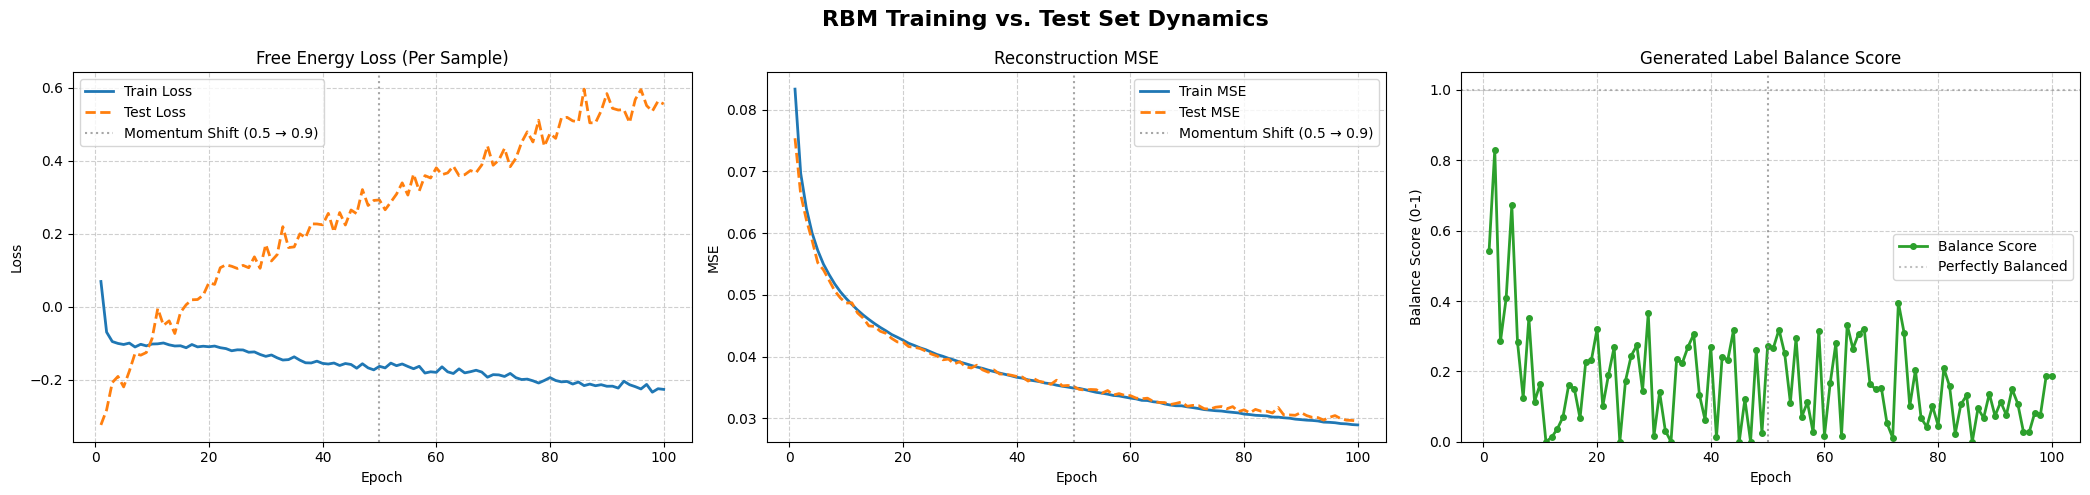

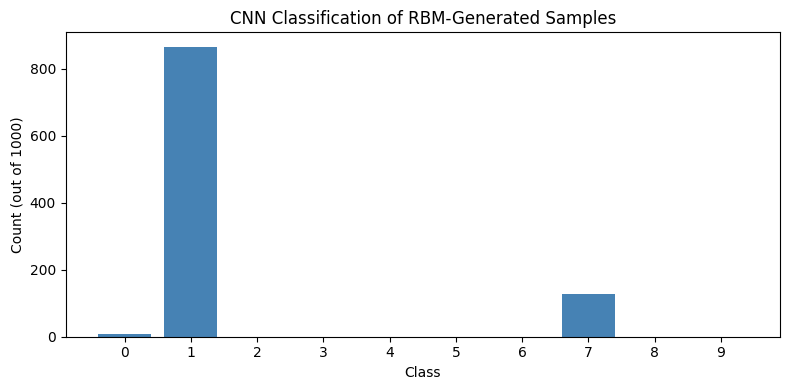

In [123]:
history = dict(
    train_loss=train_loss_history_rbm, test_loss=test_loss_history_rbm,
    train_rec_err=train_rec_err_history_rbm, test_rec_err=test_rec_err_history_rbm,
    balance_score=balance_score_history_rbm,
)
full_diagnose_rbm(model_rbm=model_rbm,
                  config_rbm=model_config,
                  history_rbm=history,
                  optimizer_rbm=optimizer_rbm,
                  model_cnn=classification_model_1)

# ========================== SAVE / LOAD ==========================

In [66]:
### SAVE
MODEL_RBM_PATH = MODELS_RBM_DIR_NAME + "std_rbm_2_bad.pt"

In [67]:
### SAVE THE TRAINING RESULTS ON LOCAL STORAGE
save_rbm_checkpoint(model_rbm, optimizer_rbm, epoch + 1, model_config, history, MODEL_RBM_PATH)

NameError: name 'epoch' is not defined

In [19]:
### Plot training history
def plot_training_curves_sep(train_loss, test_loss, train_rec_err, test_rec_err, balance_score_history, momentum_switch: int):
    """
    Plots Train vs Test Free Energy Loss, Reconstruction MSE, and Label Balance Score
    over epochs, each as its own separate figure.
    """
    epochs = range(1, len(train_loss) + 1)

    # ---------------------------------------------------------------- Figure 1: Free Energy Loss
    fig1, ax1 = plt.subplots(figsize=(7, 5))
    fig1.suptitle("Free Energy Loss (Per Sample)", fontsize=14, fontweight="bold")
    ax1.plot(epochs, train_loss, label="Train Loss", color="#1f77b4", linewidth=2.0)
    ax1.plot(epochs, test_loss, label="Test Loss", color="#ff7f0e", linewidth=2.0, linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        ax1.axvline(x=momentum_switch, color="gray", linestyle=":", alpha=0.7,
                    label="Momentum Shift (0.5 → 0.9)")
    ax1.legend()
    fig1.tight_layout()
    plt.show()

    # ---------------------------------------------------------------- Figure 2: Reconstruction MSE
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    fig2.suptitle("Reconstruction MSE", fontsize=14, fontweight="bold")
    ax2.plot(epochs, train_rec_err, label="Train MSE", color="#1f77b4", linewidth=2.0)
    ax2.plot(epochs, test_rec_err, label="Test MSE", color="#ff7f0e", linewidth=2.0, linestyle="--")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE")
    ax2.grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        ax2.axvline(x=momentum_switch, color="gray", linestyle=":", alpha=0.7,
                    label="Momentum Shift (0.5 → 0.9)")
    ax2.legend()
    fig2.tight_layout()
    plt.show()

    # ---------------------------------------------------------------- Figure 3: Label Balance Score
    fig3, ax3 = plt.subplots(figsize=(7, 5))
    fig3.suptitle("Generated Label Balance Score", fontsize=14, fontweight="bold")
    if balance_score_history:
        balance_epochs, balance_scores = zip(*balance_score_history)
        ax3.plot(balance_epochs, balance_scores, label="Balance Score", color="#2ca02c",
                 linewidth=2.0, marker="o", markersize=4)
    ax3.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="Perfectly Balanced")
    ax3.set_ylim(0, 1.05)
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Balance Score (0-1)")
    ax3.grid(True, linestyle="--", alpha=0.6)
    if len(epochs) >= 5:
        ax3.axvline(x=momentum_switch, color="gray", linestyle=":", alpha=0.7)
    ax3.legend()
    fig3.tight_layout()
    plt.show()

BEST MODEL: 71_pcd_k_parallel_tempering.pt

BASLINE PCDK: std_rbm_.tp

BASELINE default skin: NOT HERE

TS-PCDK model: BAD_ts_pcdk_rbm_2

TS_CDK model: ts_rbm_1.pt

In [31]:
### LOAD 
MODEL_RBM_PATH = MODELS_RBM_DIR_NAME + "71_pcd_k_parallel_tempering.pt"

In [32]:
model_rbm_1, optimizer_rbm_1, start_epoch_rbm, config_rbm_1, history_rbm_1 = load_rbm_checkpoint(
    MODEL_RBM_PATH, rbm_class=RBM, device=device,
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs=dict(lr=ALPHA, momentum=FINAL_MOMENTUM, weight_decay=WEIGHT_DECAY),
)

starting pre-training of visible biases...
pre-training finished
checkpoint loaded <- models/71_pcd_k_parallel_tempering.pt  (resuming from epoch 72)


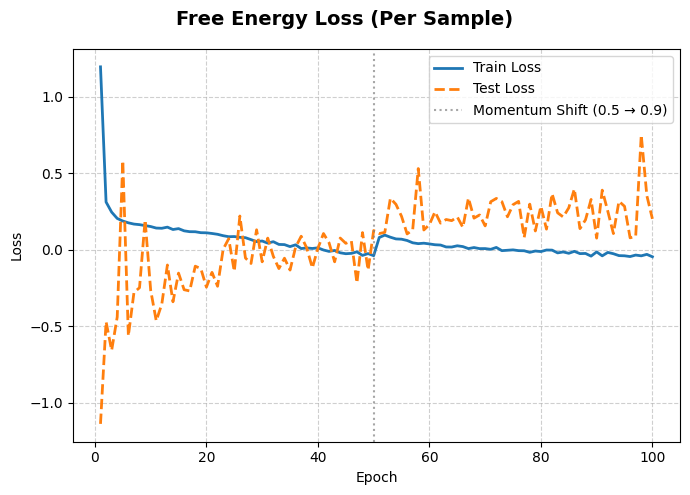

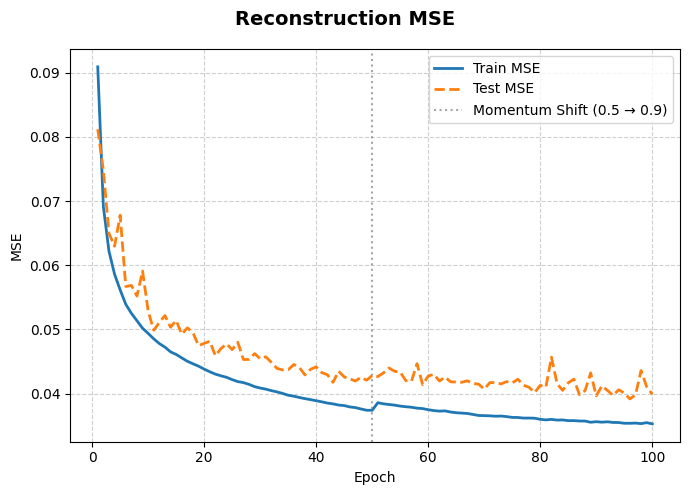

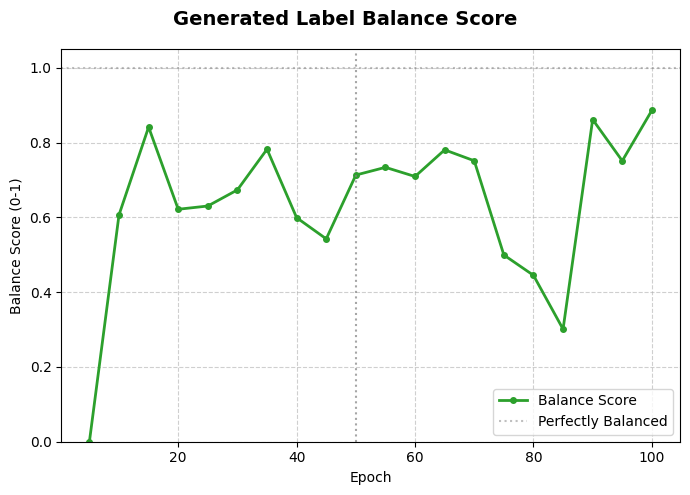

In [22]:

plot_training_curves_sep(history_rbm_1['train_loss'], history_rbm_1['test_loss'], 
                         history_rbm_1['train_rec_err'], history_rbm_1['test_rec_err'],
                         history_rbm_1.get('balance_score', []),
                         MOMENTUM_SWITCH)

  hidden_N                       = 2000
  CDK_limit                      = 4
  pt_num_temp_plains             = 5
  pt_temp_max                    = 2.0
  ts_num_slices                  = 7
  ts_gamma_init                  = 2.0
  ts_gamma_final                 = 0.05
  ts_coupling_scale              = 1.0
  sparsity_target                = 0.01
  sparsity_cost                  = 0.01
  sparsity_decay                 = 0.98
  pfc_to_batch_ratio             = 12
  pfc_chain_reset_p              = 0.02
  mode_stability_walk_steps      = 15
  mode_stability_cost            = 0.01
  mode_stability_margin          = 0.0
  mode_stability_batch_fraction  = 0.5
  use_sparsity                   = True
  use_mode_stab_penalty          = True
Optimizer Configuration:
  type: SGD
  param_group[0]:
    lr              = 0.002
    momentum        = 0.2
    dampening       = 0
    weight_decay    = 0.0005
    nesterov        = False
    maximize        = False
    foreach         = None
    different

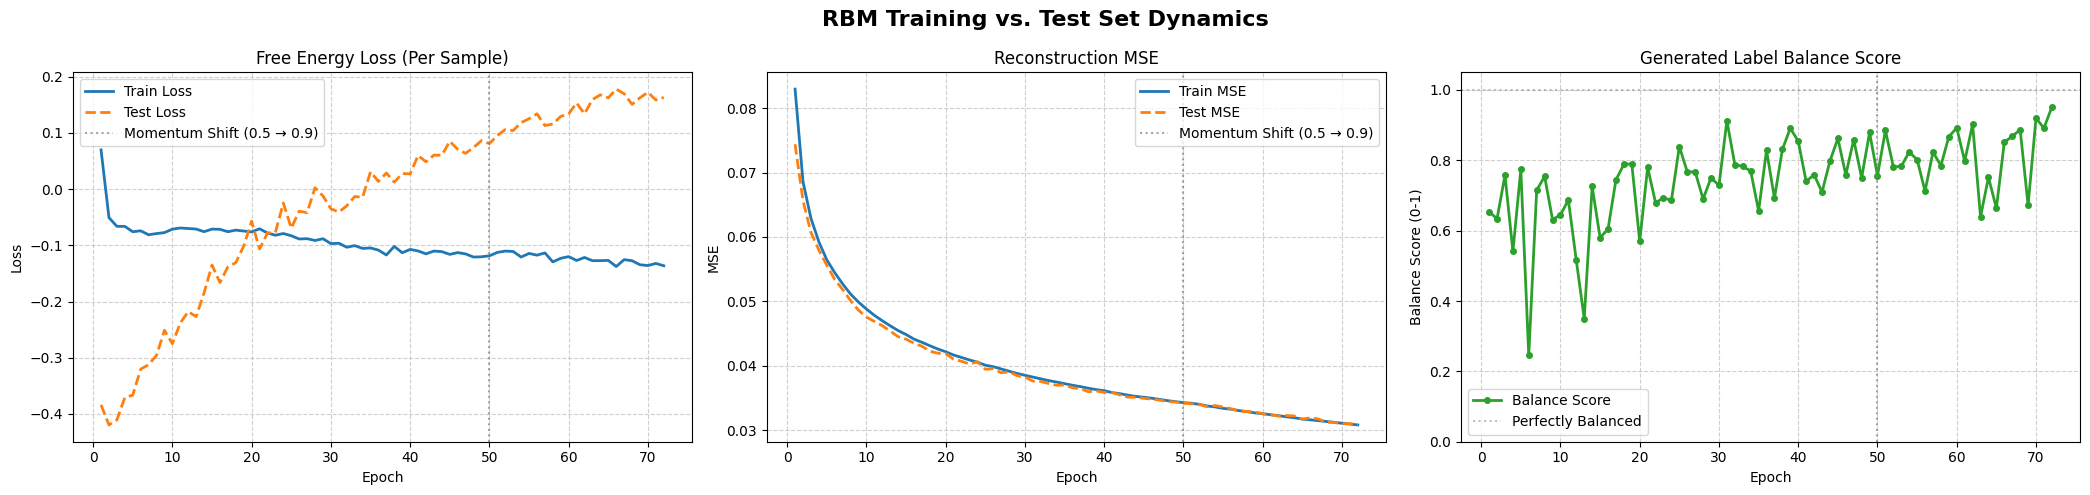

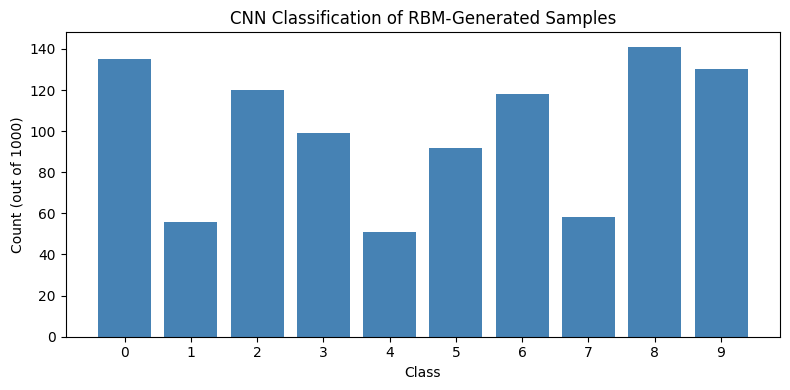

balance score of the distribution of plotted labels 0.9750687876800981


In [33]:
full_diagnose_rbm(model_rbm=model_rbm_1,
                  config_rbm=config_rbm_1,
                  history_rbm=history_rbm_1,
                  optimizer_rbm=optimizer_rbm_1,
                  model_cnn=classification_model_1)

### Test the generated images

When the model is not ideally trained, the thermal annealing actually works worst for multi class data
allowing freer movement between the low energy wells means that if you have one class with a shallower well it will be easier
for the model to jump away from it to a better recognized class.

This is happening now where most generated samples are zeros.

best cggaret of my life key bsord stck omg i see a 9

Epoch [24/30] | Free Energy Loss: -0.8986 | Rec MSE: 0.06767

### Distribution of generated images using CNN Classifier

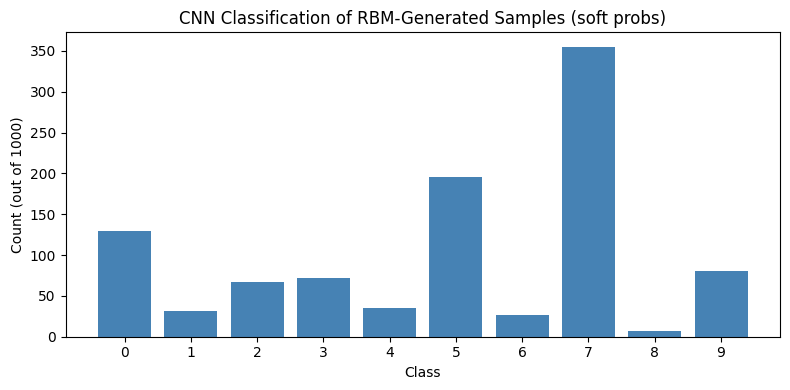

In [23]:
num_images = 1000
G_STEPS = 1000
generated_probs, state_energies, _ = model_rbm_1.gibbs_data_gen_TA(num_samples=num_images, 
                                                                   gibbs_steps=G_STEPS, 
                                                                   use_thermal_annealing=False)

counts, fractions, N = flat_get_classification_distribution(classification_model_1, 
                                                            generated_probs, 
                                                            device)

plot_distribution_histogram(counts, N, title="CNN Classification of RBM-Generated Samples (soft probs)")

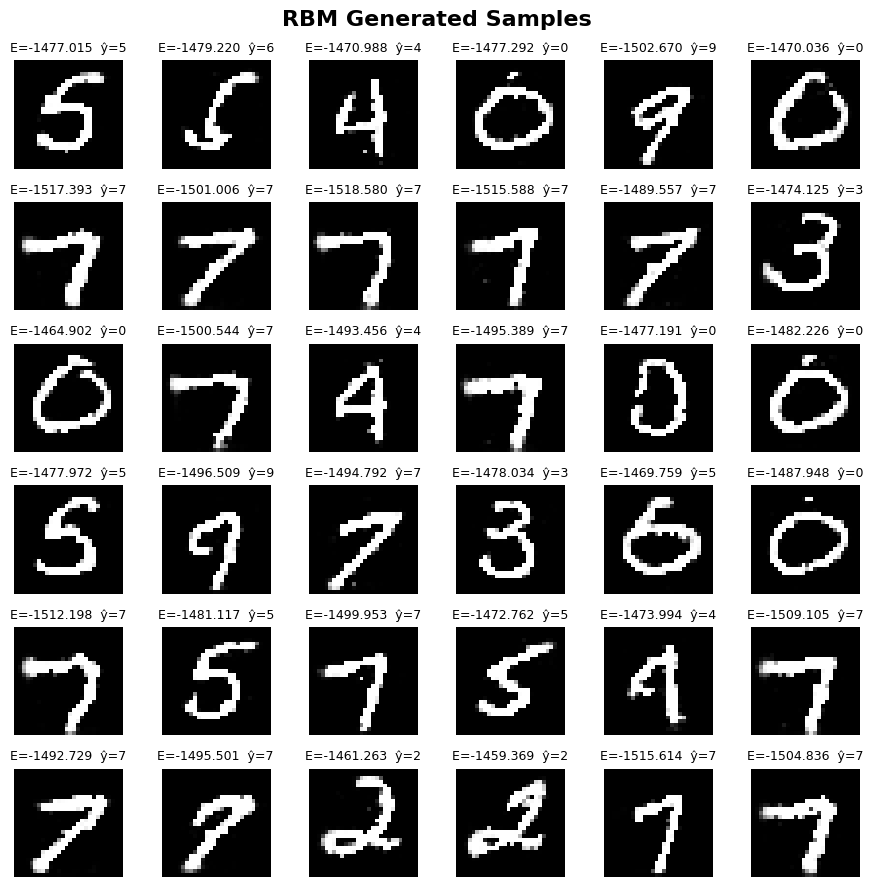

In [96]:
num_images = 36
g_steps = 1000
generated_probs, state_energies, _ = model_rbm_1.gibbs_data_gen_TA(num_samples=num_images, gibbs_steps=g_steps, use_thermal_annealing=False)

plot_generated_samples_with_labels(generated_probs, state_energies, classification_model_1, device)

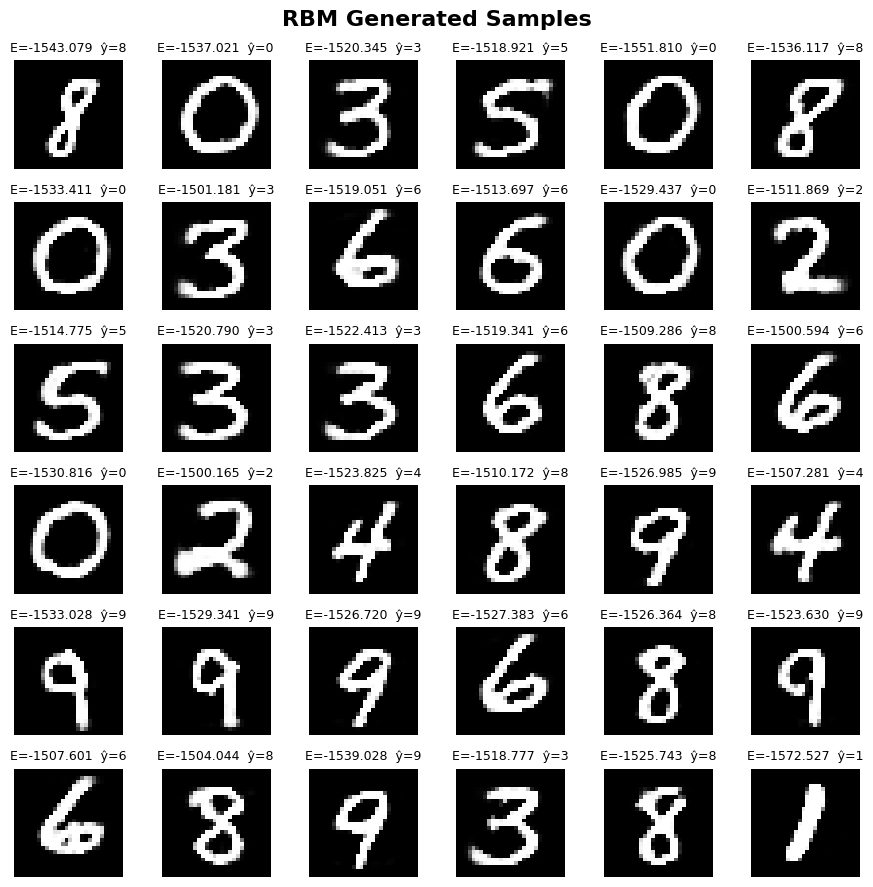

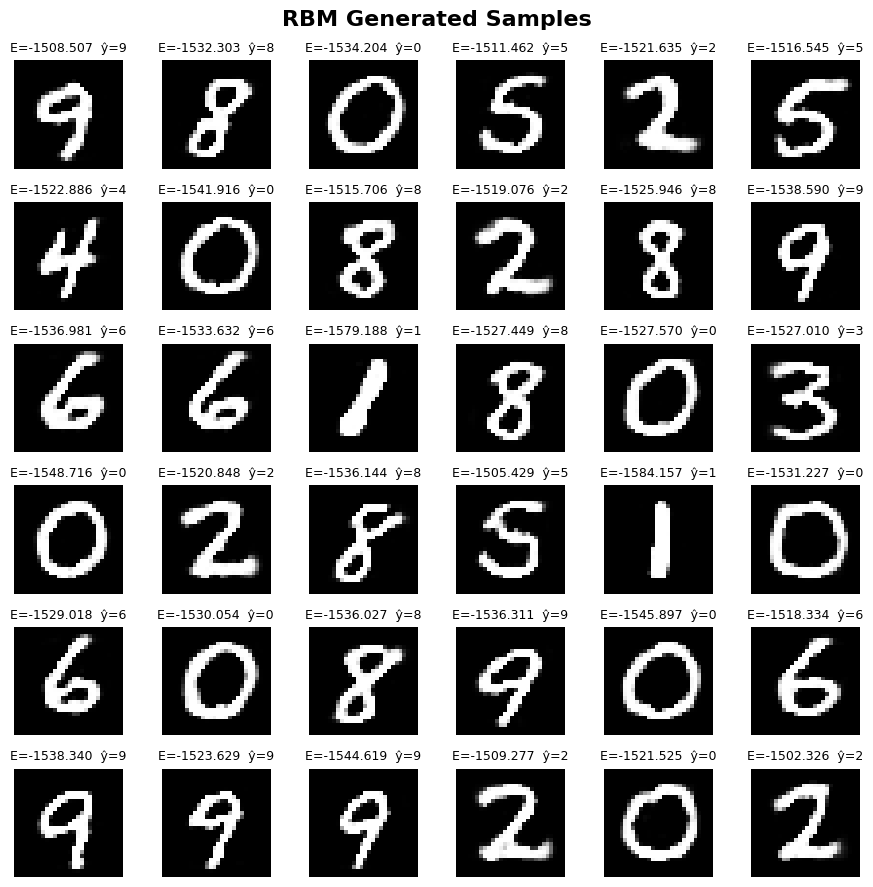

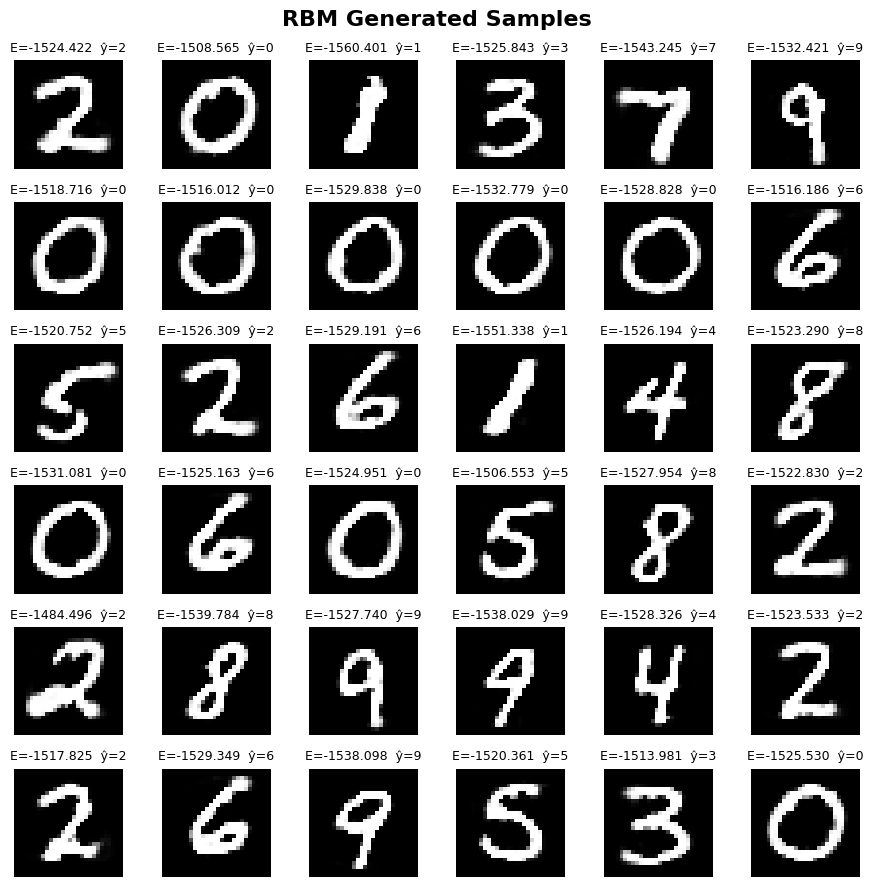

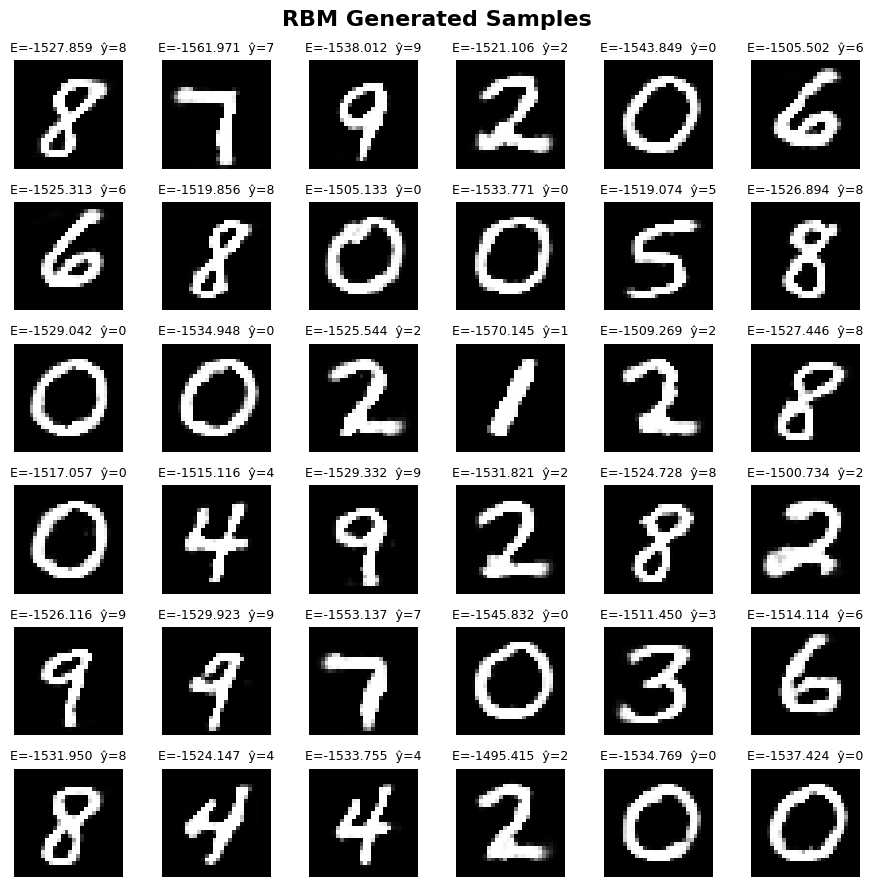

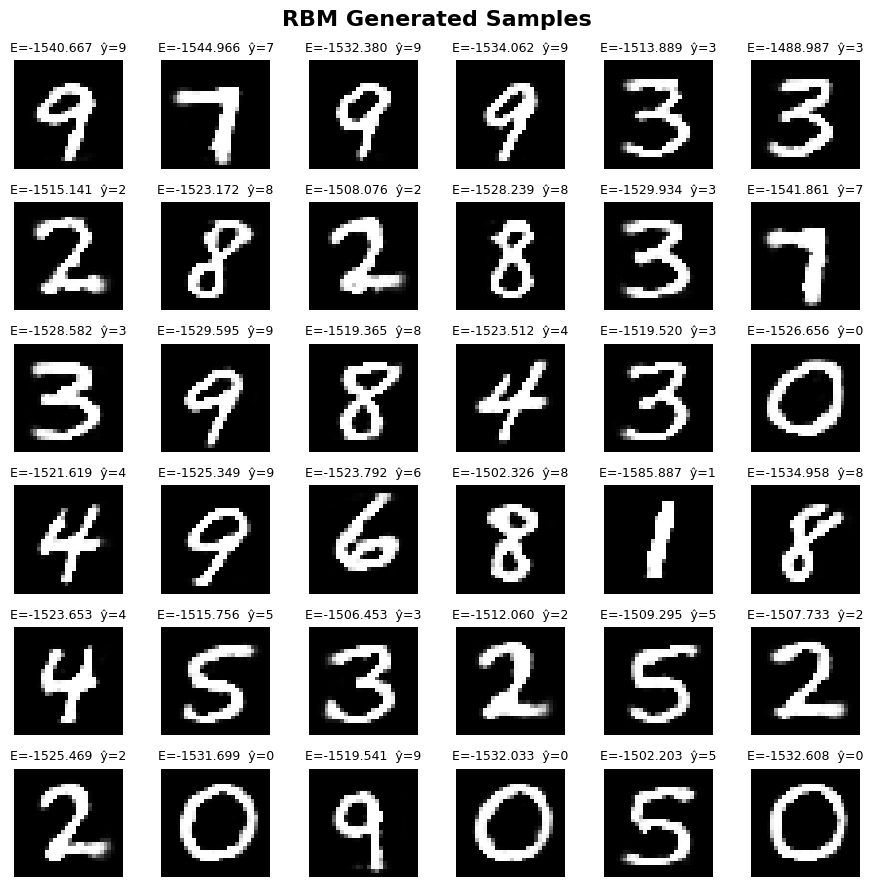

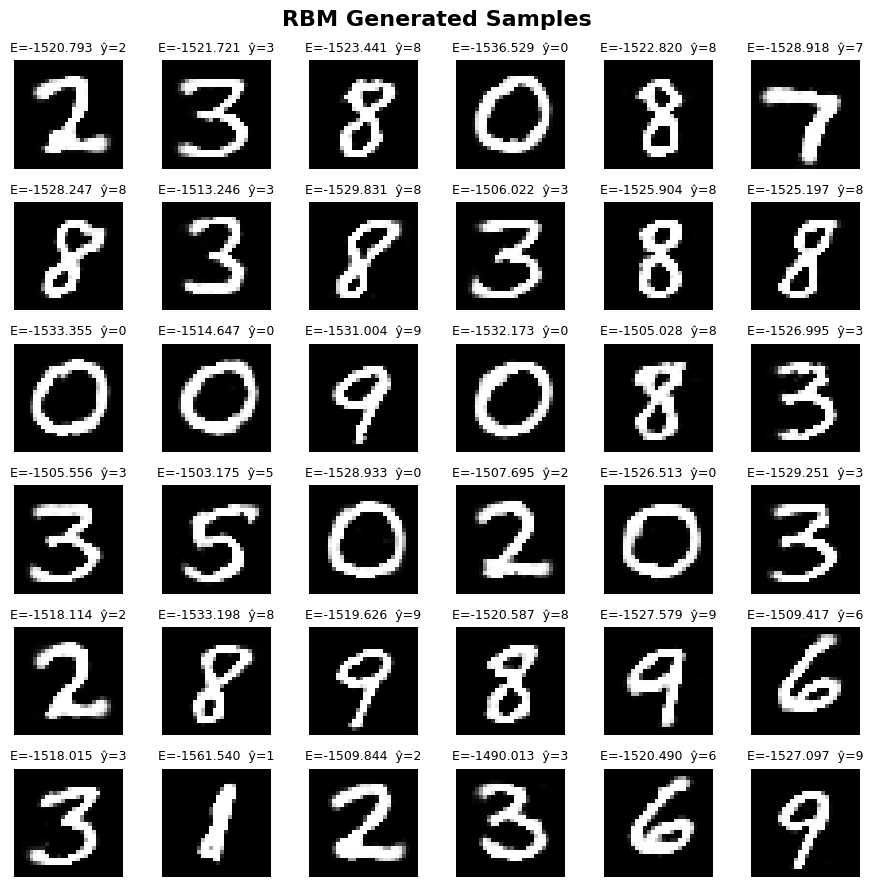

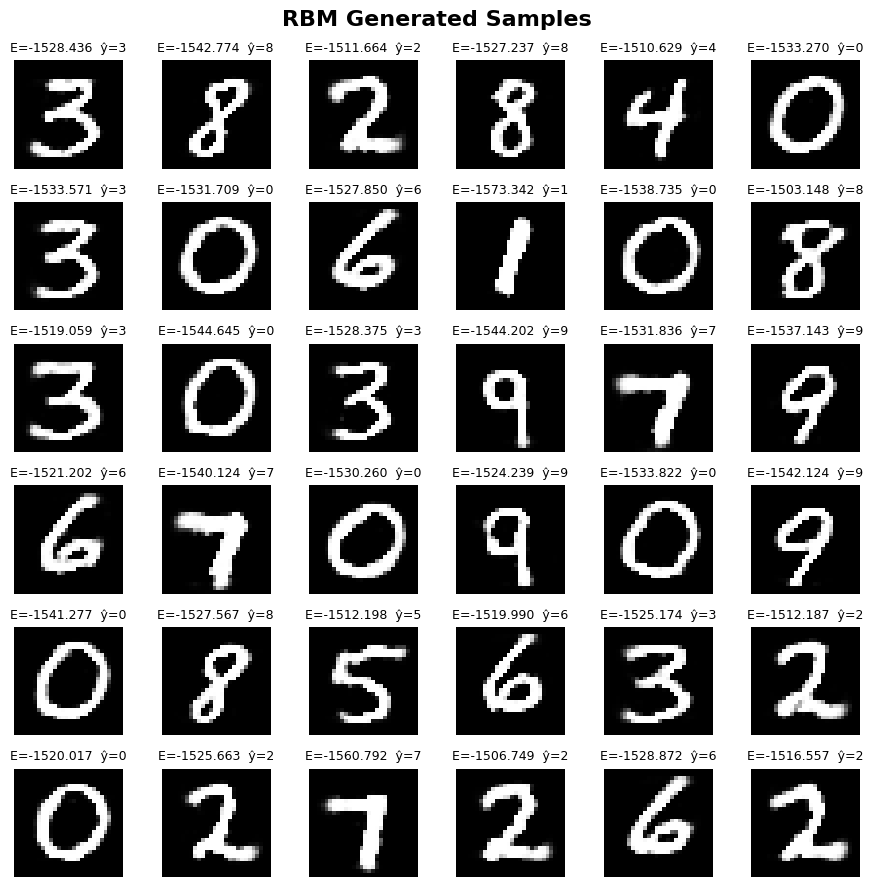

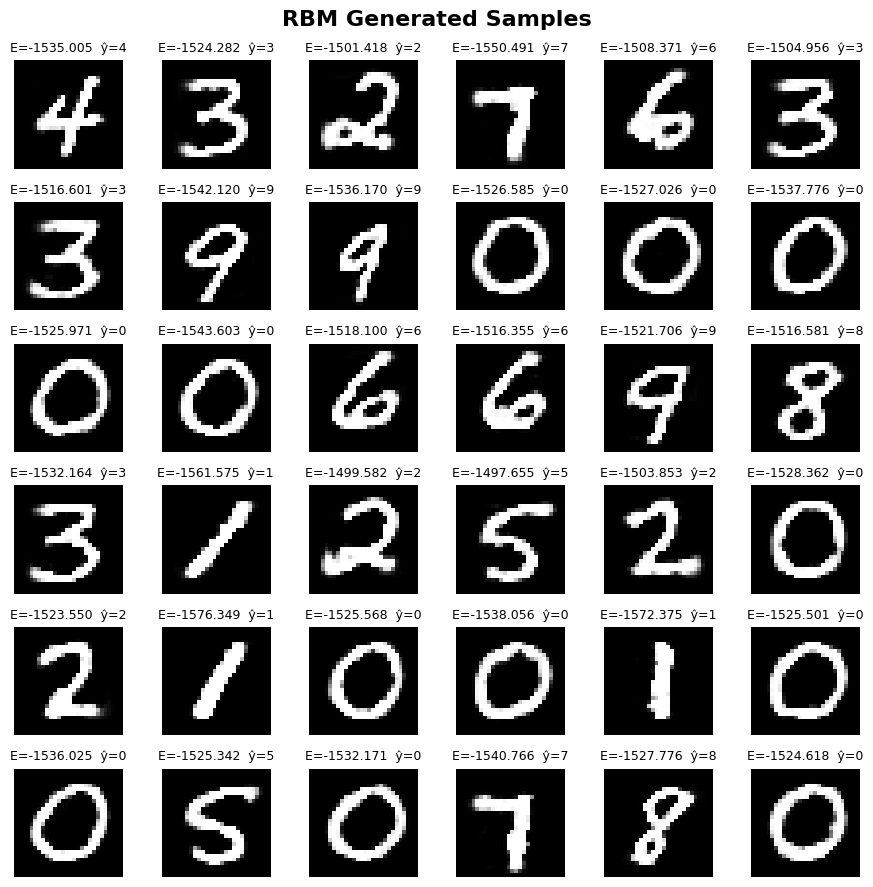

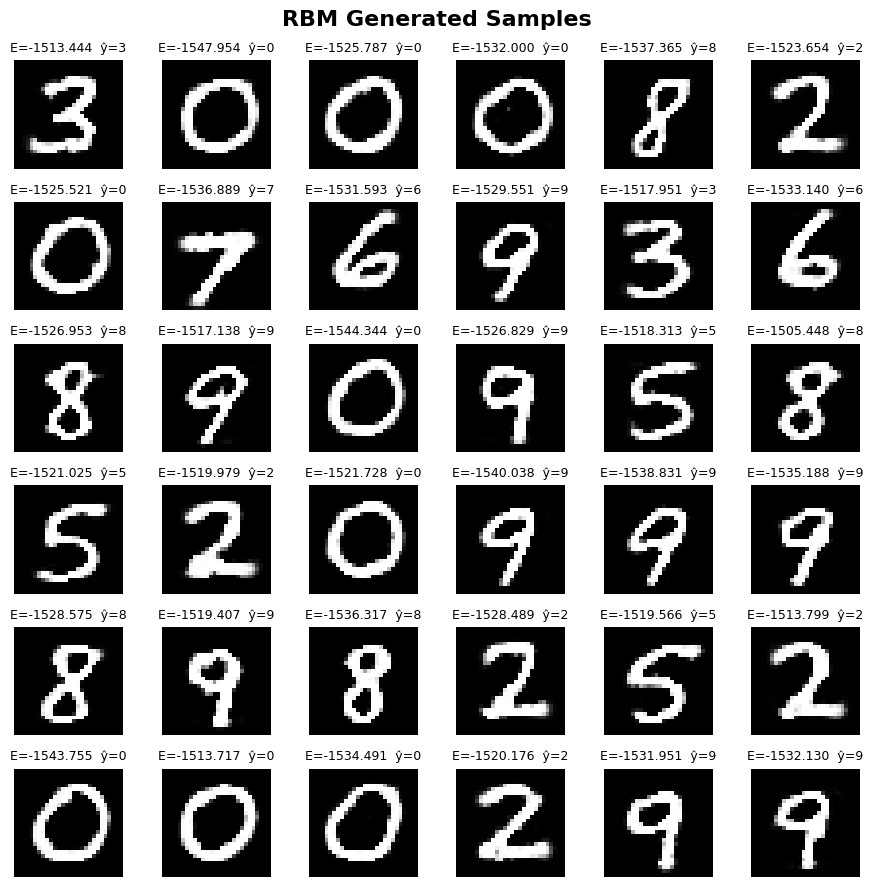

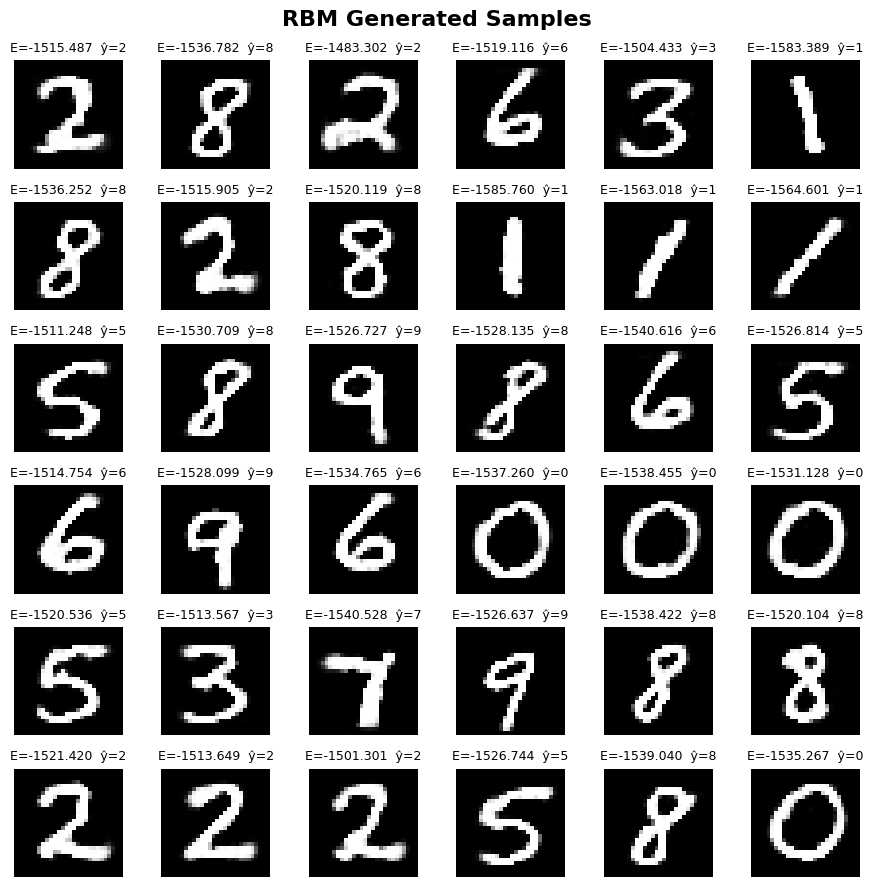

In [34]:
for _ in range(10):
    num_images = 36
    G_STEPS = 1000
    generated_probs, state_energies, _ = model_rbm_1.gibbs_data_gen_TA(num_samples=num_images, gibbs_steps=G_STEPS, use_thermal_annealing=False)

    plot_generated_samples_with_labels(generated_probs, state_energies, classification_model_1, device)

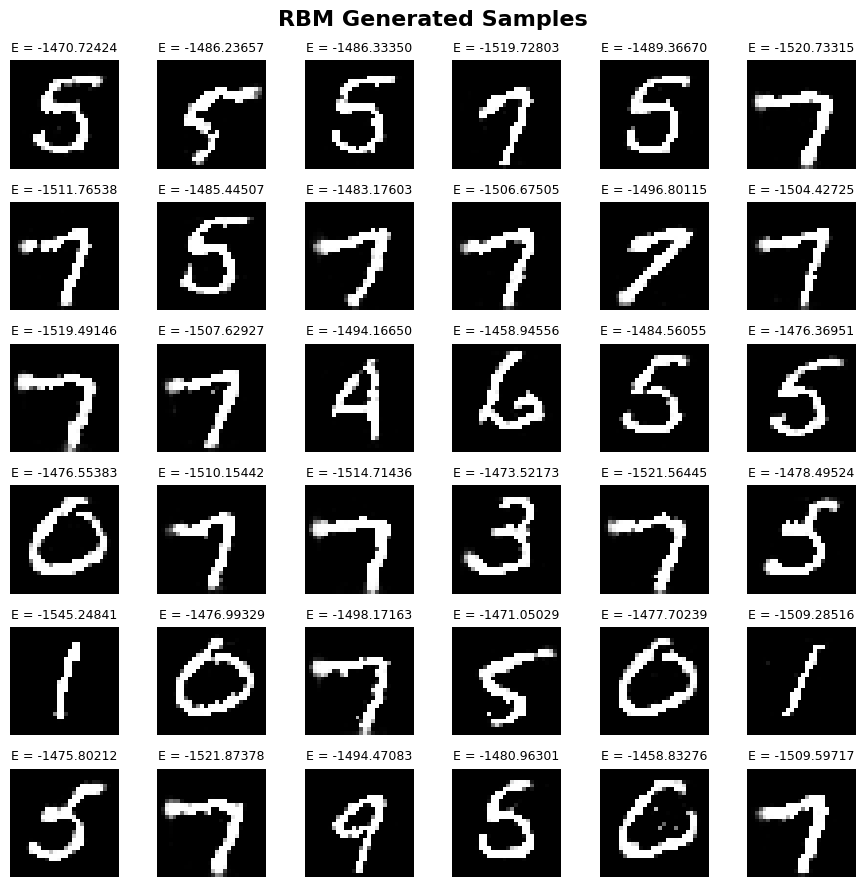

In [30]:
# max temperature
TEMPERATURE = 1.05
num_images = 36
G_STEPS = 1000
generated_probs, state_energies, _ = model_rbm_1.gibbs_data_gen_TA(num_samples=num_images, gibbs_steps=G_STEPS, 
                                                          use_thermal_annealing=True, initial_temperature=TEMPERATURE)
plot_generated_samples(generated_probs, state_energies)

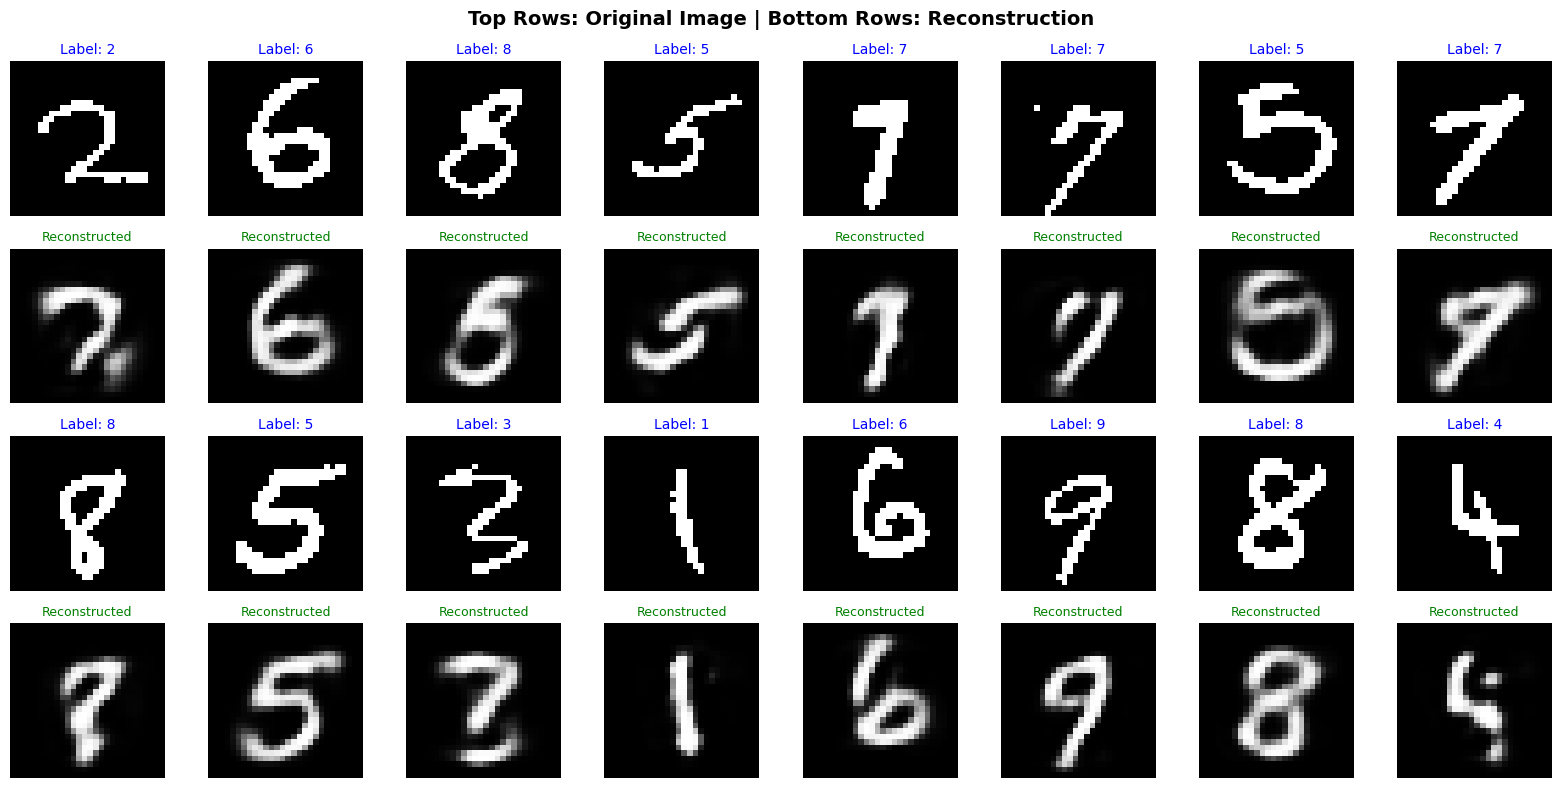

In [ ]:
test_dataset_flat = dataset["test"].with_transform(preprocess_images_flat)
test_loader = DataLoader(
    test_dataset_flat,
    batch_size=16,
    shuffle=True,
    collate_fn=lambda x: (
        torch.stack([item["image"] for item in x]),
        torch.tensor([item["label"] for item in x]),
    ),
)

# Fetch a batch of test data
real_imgs, true_labels = next(iter(test_loader))
real_imgs = real_imgs.to(device)

# Reconstruction pass
model_rbm.eval()
with torch.no_grad():
    v_prob, _ = model_rbm(real_imgs)

# Move tensors to CPU
real_imgs_cpu = real_imgs.cpu()
v_prob_cpu = v_prob.cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(
    "Top Rows: Original Image | Bottom Rows: Reconstruction",
    fontsize=14,
    fontweight="bold",
)

for i in range(16):
    row_offset = (i // 8) * 2
    col = i % 8

    # Original Image Tensor
    ax_orig = axes[row_offset, col]
    ax_orig.imshow(real_imgs_cpu[i].view(28, 28), cmap="gray")
    ax_orig.set_title(f"Label: {true_labels[i].item()}", fontsize=10, color="blue")
    ax_orig.axis("off")

    # Reconstructed Image Tensor
    ax_rec = axes[row_offset + 1, col]
    ax_rec.imshow(v_prob_cpu[i].view(28, 28), cmap="gray")
    ax_rec.set_title("Reconstructed", fontsize=9, color="green")
    ax_rec.axis("off")

plt.tight_layout()
plt.show()

TEST / EVAL

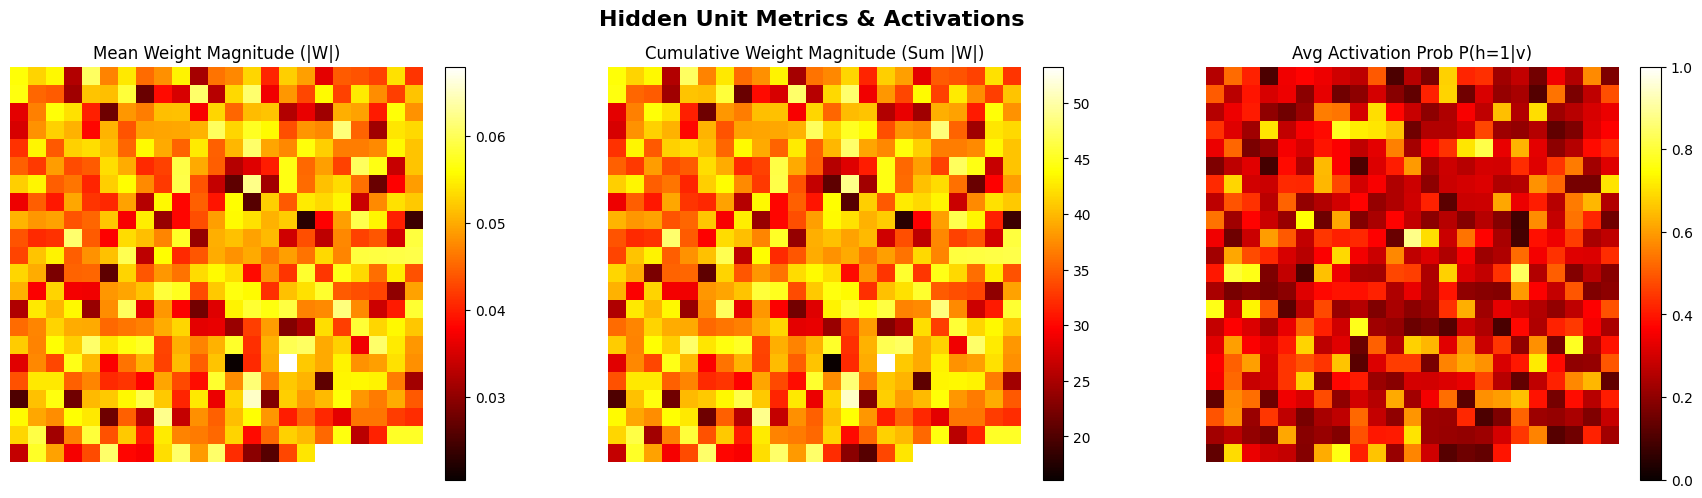

In [ ]:
### run the test
num_images = 36
G_STEPS = 1000
_, _, h_probs = model_rbm.gibbs_data_gen_TA(num_samples=num_images, gibbs_steps=G_STEPS, use_thermal_annealing=False)

plot_hidden_unit_heatmaps(model_rbm, h_probs)

fin
